# Mobile Money Fraud Detection

## AI Engineering Challenge - Phase 1: Data Science

**Candidate Name:** [Western Onzere]
**Date:** [March 17, 2026]

---

## Table of Contents

1. [Setup & Data Loading](#1-setup--data-loading)
2. [Exploratory Data Analysis](#2-exploratory-data-analysis)
   - 2.1 Basic Statistics
   - 2.2 Target Variable Analysis
   - 2.3 Temporal Analysis
   - 2.4 Transaction Type Analysis
   - 2.5 Amount Analysis
   - 2.6 Geographic Analysis
   - 2.7 User Behavior Analysis
3. [Feature Engineering](#3-feature-engineering)
   - 3.1 Temporal Features
   - 3.2 Transaction Velocity Features
   - 3.3 Amount-Based Features
   - 3.4 Behavioral Features
   - 3.5 Device & Location Features
4. [Data Preprocessing](#4-data-preprocessing)
5. [Model Development](#5-model-development)
   - 5.1 Baseline Model
   - 5.2 Model Comparison
   - 5.3 Hyperparameter Tuning
   - 5.4 Final Model Evaluation
6. [Model Interpretation](#6-model-interpretation)
7. [Conclusions & Next Steps](#7-conclusions--next-steps)
8. [Test Set Predictions](#8-test-set-predictions) ⭐ REQUIRED

---

## 1. Setup & Data Loading

In [28]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Set display options
pd.set_option('display.max_columns', None)
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

In [29]:
# Load the data
from pathlib import Path

FILE_PATH = Path("../data/transactions.csv")
df = pd.read_csv(FILE_PATH)
print(f"Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")

Dataset loaded: 50,000 rows × 14 columns


In [30]:
# Basic data inspection
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   transaction_id           50000 non-null  object 
 1   timestamp                50000 non-null  object 
 2   sender_id                50000 non-null  object 
 3   receiver_id              50000 non-null  object 
 4   amount                   50000 non-null  float64
 5   transaction_type         50000 non-null  object 
 6   sender_balance_before    50000 non-null  float64
 7   sender_balance_after     50000 non-null  float64
 8   receiver_balance_before  50000 non-null  float64
 9   receiver_balance_after   50000 non-null  float64
 10  device_id                50000 non-null  object 
 11  location_lat             50000 non-null  float64
 12  location_lon             50000 non-null  float64
 13  is_fraud                 50000 non-null  int64  
dtypes: float64(7), int64(1

In [31]:
df.head()

,transaction_id,timestamp,sender_id,receiver_id,amount,transaction_type,sender_balance_before,sender_balance_after,receiver_balance_before,receiver_balance_after,device_id,location_lat,location_lon,is_fraud
0,6EB4D46BA1B3D436,2024-01-01 00:24:12,USR000197,USR006604,701.74,send_money,93725.40,93023.66,155223.20,155924.94,DEV00009299,-0.479970,39.534387,0
1,B6483765E2F120B3,2024-01-01 01:21:24,USR003827,USR001772,262.18,pay_bill,168781.46,168519.28,71813.67,72075.85,DEV00007045,-1.025984,37.128477,0
2,1FFF0622A1441845,2024-01-01 01:33:17,USR007516,USR004366,446.42,send_money,140544.59,140098.17,40409.07,40855.49,DEV00007637,-0.570625,34.854586,0
3,4EE0C335368E4144,2024-01-01 01:53:47,USR002133,USR002447,69999.00,pay_bill,162797.10,92798.10,124725.77,194724.77,DEV00010447,4.514332,32.957873,1
4,D769B217438B8593,2024-01-01 02:03:26,USR001867,USR007013,75000.00,send_money,122467.79,47467.79,132308.22,207308.22,DEV00010154,-2.692356,37.730200,1


In [32]:
df.shape

(50000, 14)

In [33]:
df.tail()

,transaction_id,timestamp,sender_id,receiver_id,amount,transaction_type,sender_balance_before,sender_balance_after,receiver_balance_before,receiver_balance_after,device_id,location_lat,location_lon,is_fraud
49995,718FE22F4181DE1F,2024-06-30 22:32:35,USR003053,USR001625,5152.67,withdraw,174173.69,169021.02,47440.12,52592.79,DEV00003627,-1.486951,37.272080,0
49996,9AC60F8D01848878,2024-06-30 22:50:21,USR005059,USR004722,7272.73,pay_bill,193745.69,186472.96,81051.29,88324.02,DEV00004616,-3.265546,40.198369,0
49997,B0385D2986D6B18F,2024-06-30 22:57:01,USR001995,USR000804,456.58,send_money,196609.77,196153.19,53060.00,53516.58,DEV00008566,-4.109794,39.627059,0
49998,81F795C5D963DC4C,2024-06-30 23:02:21,USR004757,USR006471,1572.43,pay_bill,12974.79,11402.36,130283.27,131855.70,DEV00009392,-1.004188,37.091143,0
49999,4DE586786E5CA73E,2024-06-30 23:49:32,USR007463,USR000121,11962.97,deposit,157610.20,145647.23,162721.82,174684.79,DEV00005827,-3.150968,40.085452,0


## Missing values


In [34]:
missing_values = df.isnull().sum()
if missing_values.sum() > 0:
    print("\n--- Missing Values Found ---")
    print(missing_values[missing_values > 0])
else:
    print("\nNo missing values found.")



No missing values found.


In [35]:
# Check for duplicates
duplicates = df.duplicated(subset=['transaction_id']).sum()
print(f"\nDuplicate transaction_ids: {duplicates}")



Duplicate transaction_ids: 0


In [36]:
# Look at categorical variety
categorical_cols = df.select_dtypes(include=['object']).columns
print("\n--- Unique counts for Categorical Columns ---")
for col in categorical_cols:
    if col != 'transaction_id':
        print(f"{col}: {df[col].nunique()} unique values")


--- Unique counts for Categorical Columns ---
timestamp: 49879 unique values
sender_id: 7985 unique values
receiver_id: 7979 unique values
transaction_type: 5 unique values
device_id: 7926 unique values


---

## 2. Exploratory Data Analysis

### 2.1 Basic Statistics

In [37]:
print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)
print(f"Total transactions : {len(df):,}")
print(f"Time period        : {df['timestamp'].min()} → {df['timestamp'].max()}")
print(f"Unique senders     : {df['sender_id'].nunique():,}")
print(f"Unique receivers   : {df['receiver_id'].nunique():,}")
print(f"Unique devices     : {df['device_id'].nunique():,}")
print(f"Transaction types  : {df['transaction_type'].unique()}")
print(f"Fraud cases        : {df['is_fraud'].sum():,} ({df['is_fraud'].mean()*100:.2f}%)")

DATASET OVERVIEW
Total transactions : 50,000
Time period        : 2024-01-01 00:24:12 → 2024-06-30 23:49:32
Unique senders     : 7,985
Unique receivers   : 7,979
Unique devices     : 7,926
Transaction types  : ['send_money' 'pay_bill' 'buy_goods' 'withdraw' 'deposit']
Fraud cases        : 2,000 (4.00%)


#### Numeric columns analysis

In [38]:
print("\n" + "=" * 60)
print("NUMERIC COLUMN STATISTICS")
print("=" * 60)

numeric_cols = ['amount', 'sender_balance_before', 'sender_balance_after',
                'receiver_balance_before', 'receiver_balance_after']

stats = df[numeric_cols].describe().T
stats['skewness'] = df[numeric_cols].skew()
# coefficient of variation
stats['cv'] = stats['std'] / stats['mean']

print(stats.round(2))


NUMERIC COLUMN STATISTICS
                           count       mean       std      min       25%  \
amount                   50000.0    3642.59  10816.55     1.39    560.90   
sender_balance_before    50000.0  101834.25  57077.97   214.88  52692.88   
sender_balance_after     50000.0   98191.66  57117.53 -1583.76  48726.60   
receiver_balance_before  50000.0   99776.34  57646.12   113.60  50113.28   
receiver_balance_after   50000.0  103418.93  58711.53   203.11  53273.21   

                               50%        75%        max  skewness    cv  
amount                     1412.70    3203.81  206029.48      9.11  2.97  
sender_balance_before    102095.70  151298.68  204445.72     -0.01  0.56  
sender_balance_after      97762.38  147448.15  199943.73      0.02  0.58  
receiver_balance_before   99309.34  149617.67  199983.91      0.01  0.58  
receiver_balance_after   102664.54  153380.03  345638.67      0.07  0.57  


In [39]:
# --- Insights ---
amount_skew = df['amount'].skew()
median_amount = df['amount'].median()
mean_amount = df['amount'].mean()
max_amount = df['amount'].max()
fraud_rate = df['is_fraud'].mean() * 100

print(f"""
1. CLASS IMBALANCE
   - Only {fraud_rate:.2f}% of transactions are fraudulent.
   - This is expected in fraud detection but means accuracy alone is a misleading metric — we will optimize for AUC-ROC and Precision-Recall instead.

2. TRANSACTION AMOUNTS (KES)
   - Mean: KES {mean_amount:,.0f} | Median: KES {median_amount:,.0f}
   - The mean is significantly higher than the median, indicating a right-skewed distribution — a few very large transactions pull the average up. (Skewness = {amount_skew:.2f})
   - Max transaction: KES {max_amount:,.0f}
   - We will apply log-transformation to amount during feature engineering to reduce the effect of outliers.

3. BALANCE COLUMNS
   - We have sender & receiver balances before and after each
     transaction. These allow us to compute:
       * balance change (actual vs expected)
       * whether a sender drained their account completely
       * receiver balance anomalies
   - These derived features are likely to be strong fraud signals.

4. GEOGRAPHIC COVERAGE
   - Transactions include lat/lon coordinates, enabling spatial clustering analysis — fraudulent activity may concentrate in specific regions or show unusual location jumps.

5. NEGATIVE BALANCE ANOMALY
   - sender_balance_after has a minimum of KES {df['sender_balance_after'].min():,.2f}, indicating at least one sender overdrew their account.
   - This could be a data anomaly or a deliberate fraud signal (e.g. forced overdraft). We will flag transactions where sender_balance_after < 0 as a binary feature during feature engineering.
""")


1. CLASS IMBALANCE
   - Only 4.00% of transactions are fraudulent.
   - This is expected in fraud detection but means accuracy alone is a misleading metric — we will optimize for AUC-ROC and Precision-Recall instead.

2. TRANSACTION AMOUNTS (KES)
   - Mean: KES 3,643 | Median: KES 1,413
   - The mean is significantly higher than the median, indicating a right-skewed distribution — a few very large transactions pull the average up. (Skewness = 9.11)
   - Max transaction: KES 206,029
   - We will apply log-transformation to amount during feature engineering to reduce the effect of outliers.

3. BALANCE COLUMNS
   - We have sender & receiver balances before and after each
     transaction. These allow us to compute:
       * balance change (actual vs expected)
       * whether a sender drained their account completely
       * receiver balance anomalies
   - These derived features are likely to be strong fraud signals.

4. GEOGRAPHIC COVERAGE
   - Transactions include lat/lon coordinates

#### Timestamps

In [40]:
# --- Parse timestamp ---
df['timestamp'] = pd.to_datetime(df['timestamp'])
print("Timestamp parsed to datetime")
print(f"   Date range: {df['timestamp'].dt.date.min()} → {df['timestamp'].dt.date.max()}")
print(f"   Span: {(df['timestamp'].max() - df['timestamp'].min()).days} days")

Timestamp parsed to datetime
   Date range: 2024-01-01 → 2024-06-30
   Span: 181 days


In [41]:
df.shape

(50000, 14)

### 2.2 Target Variable Analysis

#### The distribution of fraud vs legitimate transactions

In [42]:
# --- Class Distribution ---
fraud_counts = df['is_fraud'].value_counts()
fraud_pct = df['is_fraud'].value_counts(normalize=True) * 100

print("=" * 60)
print("FRAUD vs LEGITIMATE DISTRIBUTION")
print("=" * 60)
print(f"Legitimate (0) : {fraud_counts[0]:,}  ({fraud_pct[0]:.2f}%)")
print(f"Fraudulent (1) : {fraud_counts[1]:,}  ({fraud_pct[1]:.2f}%)")
print(f"Imbalance ratio: {fraud_counts[0]/fraud_counts[1]:.0f}:1  (legitimate:fraud)")

FRAUD vs LEGITIMATE DISTRIBUTION
Legitimate (0) : 48,000  (96.00%)
Fraudulent (1) : 2,000  (4.00%)
Imbalance ratio: 24:1  (legitimate:fraud)


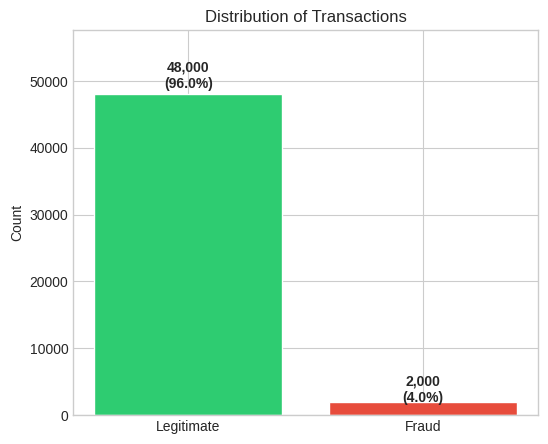

In [43]:
# --- Plot 1: Bar chart showing count of legitimate vs fraud transactions distribution  ---
plt.figure(figsize=(6, 5))
bars = plt.bar(['Legitimate', 'Fraud'], fraud_counts.values, color=['#2ecc71', '#e74c3c'])

# Add labels
for i, bar in enumerate(bars):
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + (yval*0.02),
             f'{fraud_counts.values[i]:,}\n({fraud_pct.values[i]:.1f}%)',
             ha='center', fontweight='bold')

plt.title('Distribution of Transactions')
plt.ylabel('Count')
plt.ylim(0, max(fraud_counts.values) * 1.2) # Add headroom for labels
plt.grid(False)
# Save directly to current directory
plt.savefig('eda_class_distribution.png', bbox_inches='tight')
plt.show()

In [44]:
print("A 24:1 imbalance means a naive model predicting all-legitimate scores 96% accuracy — useless for fraud detection. We will use SMOTE or class_weight='balanced' during training to compensate.")

A 24:1 imbalance means a naive model predicting all-legitimate scores 96% accuracy — useless for fraud detection. We will use SMOTE or class_weight='balanced' during training to compensate.


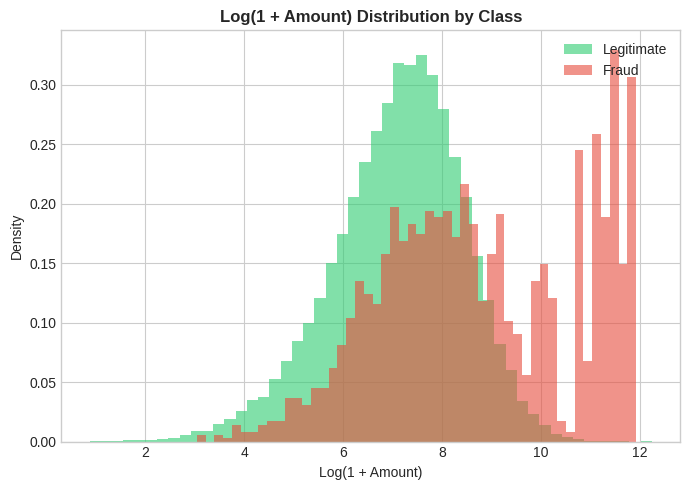

In [45]:

# --- Plot: Histogram comparing transaction amount distribution (log scale) ---
fig, ax = plt.subplots(figsize=(7, 5))

# Plotting for Legitimate (0) and Fraud (1)
for label, color, name in zip([0, 1], ['#2ecc71', '#e74c3c'], ['Legitimate', 'Fraud']):
    # Filter data and apply log transformation
    data = np.log1p(df[df['is_fraud'] == label]['amount'])

    ax.hist(
        data,
        bins=50,
        alpha=0.6,
        color=color,
        label=name,
        edgecolor='none',
        density=True # Use density to compare distributions even if imbalance is high
    )

ax.set_title('Log(1 + Amount) Distribution by Class', fontweight='bold')
ax.set_xlabel('Log(1 + Amount)')
ax.set_ylabel('Density')
ax.legend(loc='upper right')

plt.tight_layout()
plt.savefig('outputs/eda_amount_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

### Insight: High-Value Anomaly Detection potential.
- While legitimate transactions follow a unimodal distribution centered at lower amounts, fraudulent transactions show a broader, less concentrated distribution with a notable spike at high-value thresholds (Log 11+).
- Specifically, fraud shows significant spikes at high-value thresholds (Log 11+) where legitimate activity is nearly non-existent.
### Action for Feature Engineering:
- I should create features that flag "high-amount" outliers or bin these specific high-density fraud ranges, as they provide a very clear signal for the model.


#### Amount statistics split by class

In [46]:
# --- Amount statistics split by class ---
print("\n" + "=" * 60)
print("TRANSACTION AMOUNT STATS BY CLASS (KES)")
print("=" * 60)
amount_by_class = df.groupby('is_fraud')['amount'].agg(
    ['count', 'mean', 'median', 'std', 'min', 'max']
).rename(index={0: 'Legitimate', 1: 'Fraud'})
amount_by_class.columns = ['Count', 'Mean', 'Median', 'Std Dev', 'Min', 'Max']
print(amount_by_class.round(0))


TRANSACTION AMOUNT STATS BY CLASS (KES)
            Count     Mean  Median  Std Dev   Min       Max
is_fraud                                                   
Legitimate  48000   2560.0  1368.0   4049.0   1.0  206029.0
Fraud        2000  29619.0  5474.0  42773.0  20.0  149999.0


In [47]:
# --- Narrative ---
legit_median = df[df['is_fraud']==0]['amount'].median()
fraud_median = df[df['is_fraud']==1]['amount'].median()
ratio = fraud_counts[0] / fraud_counts[1]

print(f"""
{'='*60}
KEY OBSERVATIONS — TARGET VARIABLE
{'='*60}

1. SEVERE CLASS IMBALANCE
   - The dataset is highly imbalanced at {ratio:.0f}:1 (legitimate:fraud).
   - A naive model predicting all transactions as legitimate would achieve 96% accuracy — yet catch zero fraud cases.
   - Strategy: We will use class_weight='balanced' in tree-based models and apply SMOTE during preprocessing to synthetically oversample the minority class.

2. FRAUD TRANSACTIONS INVOLVE HIGHER AMOUNTS
   - Median amount — Legitimate: KES {legit_median:,.0f} | Fraud: KES {fraud_median:,.0f}
   - Fraudsters tend to target larger transactions, likely to maximise gain per attempt before detection.
   - This confirms that 'amount' will be an important feature, especially after log-transformation to handle the skew of {df['amount'].skew():.2f}..

3. IMPLICATIONS FOR MODELLING
   - Primary metric  : AUC-ROC (handles imbalance well)
   - Secondary metric: Precision-Recall AUC (focuses on minority class)
   - We will NOT use raw accuracy as a success measure.
   - A high Recall is preferred over Precision in this domain — missing a fraudulent transaction (false negative) is more costly than a false alarm (false positive).
""")


KEY OBSERVATIONS — TARGET VARIABLE

1. SEVERE CLASS IMBALANCE
   - The dataset is highly imbalanced at 24:1 (legitimate:fraud).
   - A naive model predicting all transactions as legitimate would achieve 96% accuracy — yet catch zero fraud cases.
   - Strategy: We will use class_weight='balanced' in tree-based models and apply SMOTE during preprocessing to synthetically oversample the minority class.

2. FRAUD TRANSACTIONS INVOLVE HIGHER AMOUNTS
   - Median amount — Legitimate: KES 1,368 | Fraud: KES 5,474
   - Fraudsters tend to target larger transactions, likely to maximise gain per attempt before detection.
   - This confirms that 'amount' will be an important feature, especially after log-transformation to handle the skew of 9.11..

3. IMPLICATIONS FOR MODELLING
   - Primary metric  : AUC-ROC (handles imbalance well)
   - Secondary metric: Precision-Recall AUC (focuses on minority class)
   - We will NOT use raw accuracy as a success measure.
   - A high Recall is preferred over Pr

### 2.3 Temporal Analysis

#### Transaction patterns over time (hourly, daily, weekly)

In [48]:
# Extract time components — used across all temporal plots below
df['hour']       = df['timestamp'].dt.hour
df['day_of_week'] = df['timestamp'].dt.dayofweek          # 0=Monday, 6=Sunday
df['day_name']   = df['timestamp'].dt.day_name()
df['week']       = df['timestamp'].dt.isocalendar().week.astype(int)
df['month']      = df['timestamp'].dt.month
df['date']       = df['timestamp'].dt.date

print("Temporal features extracted")
print(f"   Hours range    : {df['hour'].min()}h – {df['hour'].max()}h")
print(f"   Days covered   : {df['day_name'].unique()}")
print(f"   Weeks covered  : Week {df['week'].min()} – Week {df['week'].max()}")

Temporal features extracted
   Hours range    : 0h – 23h
   Days covered   : ['Monday' 'Tuesday' 'Wednesday' 'Thursday' 'Friday' 'Saturday' 'Sunday']
   Weeks covered  : Week 1 – Week 26


#### Hourly Transaction

#### Hourly transactions

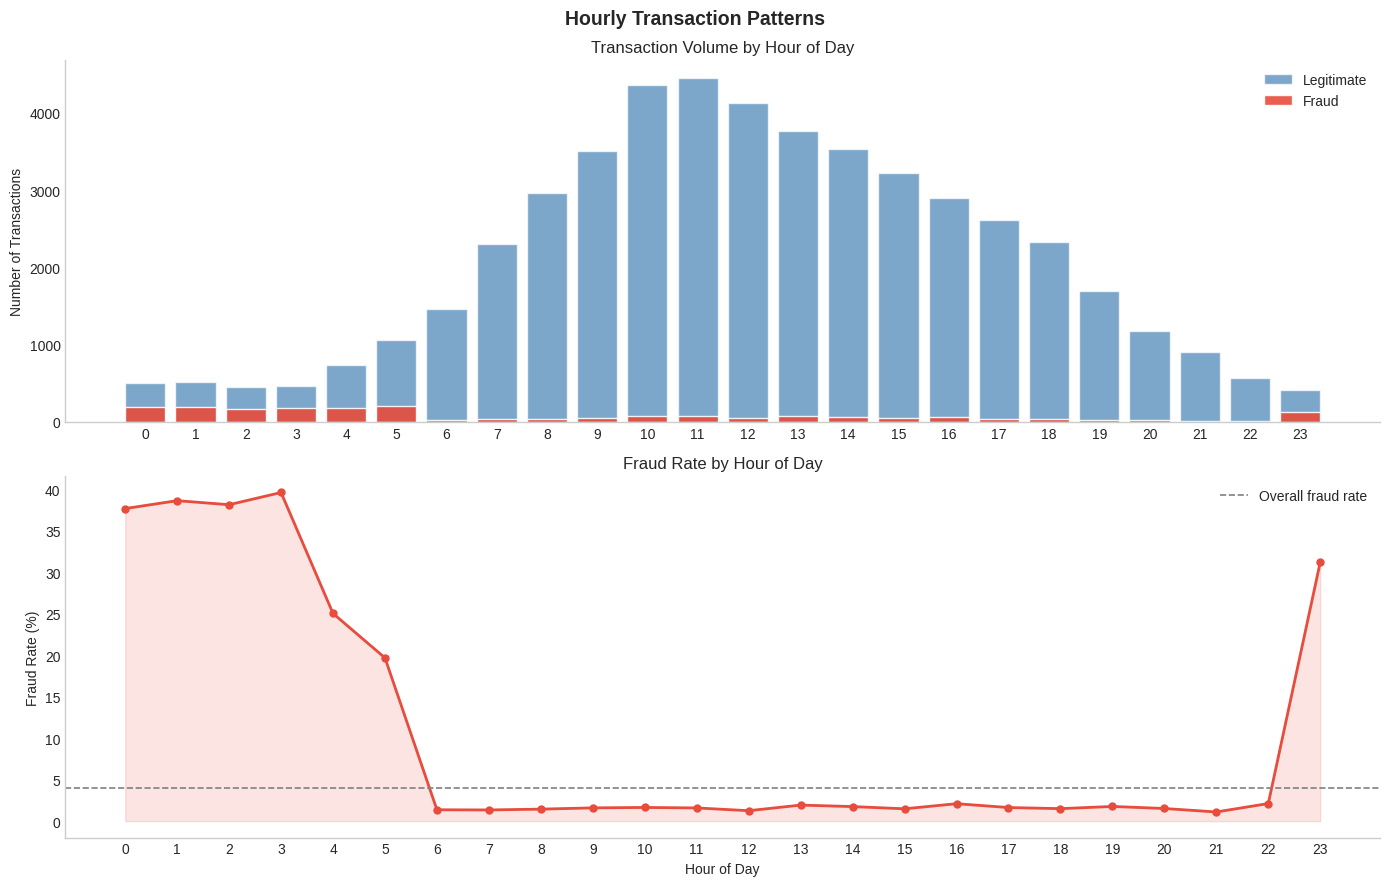


HOURLY INSIGHTS
---------------
- Peak transaction volume : 11:00h (people transacting most during business hours)
- Highest fraud rate      : 3:00h, (39.6% of transactions at that hour are fraud)
- Late-night/Off-peak hours (23h–05h) show disproportionately high fraud rates relative to transaction volume — a classic pattern where fraudsters operate when monitoring and user awareness are lowest.
- This suggests 'is_night' (23h–05h) will be a strong binary feature in our model, as the average fraud rate for these hours is about 32.9%.



In [49]:
# --- 2.3.1 Hourly Transaction Patterns ---
hourly = df.groupby('hour').agg(
    total=('is_fraud', 'count'),
    fraud=('is_fraud', 'sum')
).assign(fraud_rate=lambda x: (x['fraud'] / x['total']) * 100)

# Calculate night fraud average for insight
night_hours = [23, 0, 1, 2, 3, 4, 5]
night_fraud_avg = hourly.loc[night_hours, 'fraud_rate'].mean()

fig, axes = plt.subplots(2, 1, figsize=(14, 9))
fig.suptitle('Hourly Transaction Patterns', fontsize=14, fontweight='bold')

# Volume by hour
axes[0].bar(hourly.index, hourly['total'],
            color='steelblue', alpha=0.7, label='Legitimate')
axes[0].bar(hourly.index, hourly['fraud'],
            color='#e74c3c', alpha=0.9, label='Fraud')
axes[0].set_ylabel('Number of Transactions')
axes[0].set_title('Transaction Volume by Hour of Day')
axes[0].set_xticks(range(0, 24))
axes[0].legend()
axes[0].grid(False)

# Fraud rate by hour
axes[1].plot(hourly.index, hourly['fraud_rate'],
             color='#e74c3c', marker='o', linewidth=2, markersize=5)
axes[1].fill_between(hourly.index, hourly['fraud_rate'],
                     alpha=0.15, color='#e74c3c')
axes[1].axhline(y=df['is_fraud'].mean() * 100,
                color='gray', linestyle='--',
                linewidth=1.2, label='Overall fraud rate')
axes[1].set_xlabel('Hour of Day')
axes[1].set_ylabel('Fraud Rate (%)')
axes[1].set_title('Fraud Rate by Hour of Day')
axes[1].set_xticks(range(0, 24))
axes[1].legend()
axes[1].grid(False)

for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('outputs/eda_2_3_hourly.png', dpi=150, bbox_inches='tight')
plt.show()

# Insight
peak_fraud_hour = hourly['fraud_rate'].idxmax()
peak_volume_hour = hourly['total'].idxmax()

print(f"""
HOURLY INSIGHTS
---------------
- Peak transaction volume : {peak_volume_hour}:00h (people transacting most during business hours)
- Highest fraud rate      : {peak_fraud_hour}:00h, ({hourly.loc[peak_fraud_hour, 'fraud_rate']:.1f}% of transactions at that hour are fraud)
- Late-night/Off-peak hours (23h–05h) show disproportionately high fraud rates relative to transaction volume — a classic pattern where fraudsters operate when monitoring and user awareness are lowest.
- This suggests 'is_night' (23h–05h) will be a strong binary feature in our model, as the average fraud rate for these hours is about {night_fraud_avg:.1f}%.
""")

#### Daily Transaction Patterns

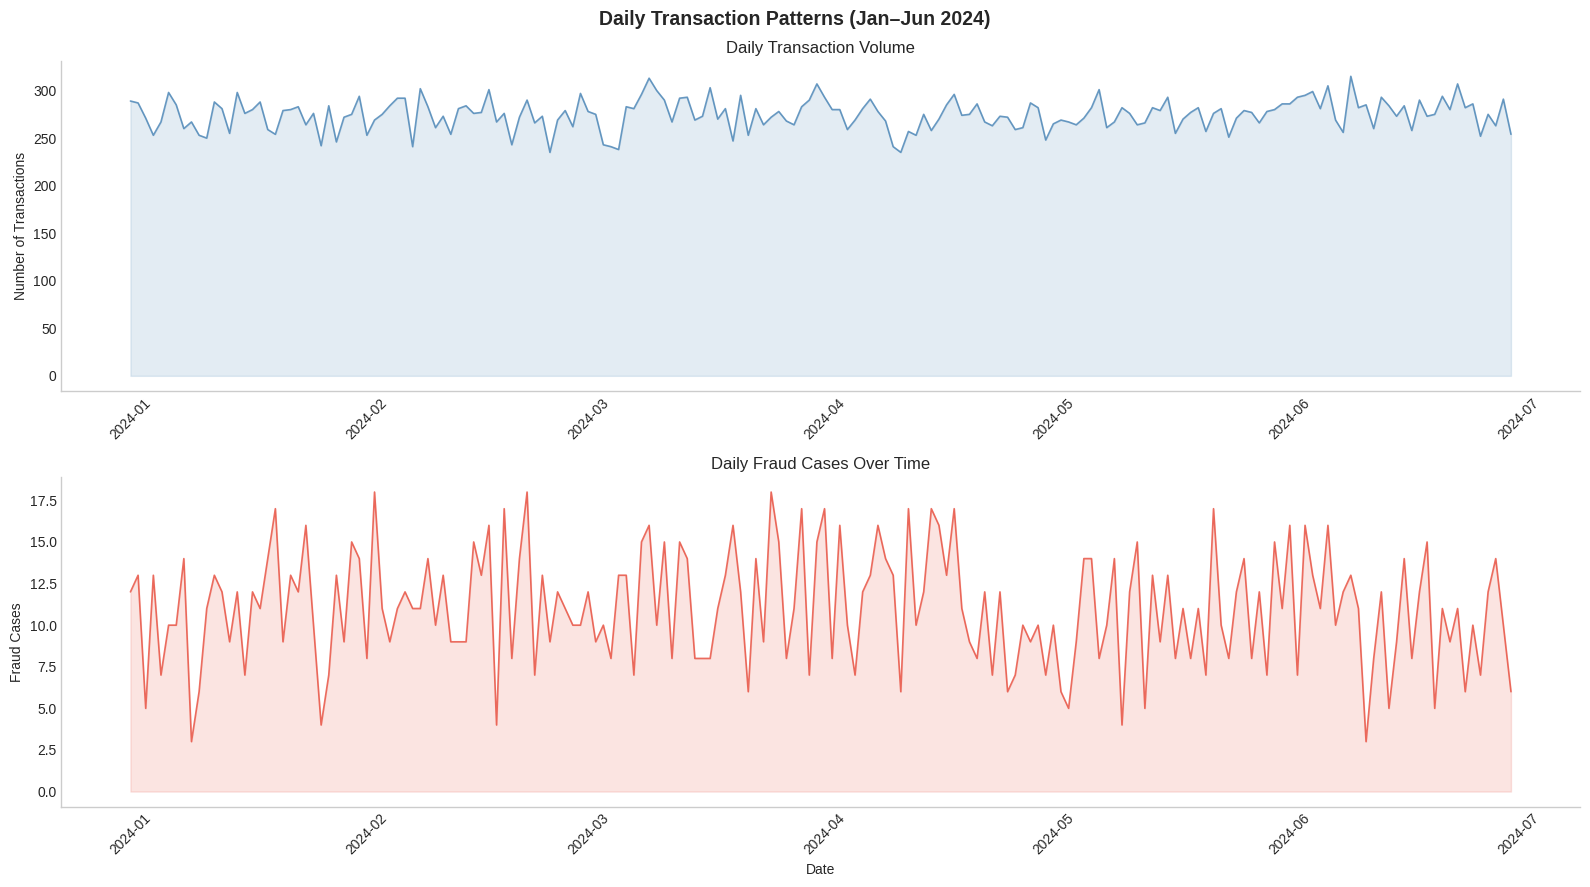


DAILY INSIGHTS
--------------
- Dataset spans 181 days (Jan 1 – Jun 30, 2024).
- Peak transaction day : 2024-06-09 (315 transactions)
- Highest fraud day    : 2024-02-02 (18 fraud cases)
- Looking for spikes in fraud count relative to volume helps identify potential coordinated fraud campaigns — sudden bursts above the rolling average are a red flag worth investigating.



In [50]:
# --- 2.3.2 Daily Transaction Patterns ---
daily = df.groupby('date').agg(
    total=('is_fraud', 'count'),
    fraud=('is_fraud', 'sum')
).assign(fraud_rate=lambda x: (x['fraud'] / x['total']) * 100)

fig, axes = plt.subplots(2, 1, figsize=(16, 9))
fig.suptitle('Daily Transaction Patterns (Jan–Jun 2024)', fontsize=14, fontweight='bold')

# Daily volume over time
axes[0].plot(daily.index, daily['total'], color='steelblue',
             linewidth=1.2, alpha=0.8)
axes[0].fill_between(daily.index, daily['total'], alpha=0.15, color='steelblue')
axes[0].set_ylabel('Number of Transactions')
axes[0].set_title('Daily Transaction Volume')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(False)

# Daily fraud count over time
axes[1].plot(daily.index, daily['fraud'], color='#e74c3c',
             linewidth=1.2, alpha=0.8)
axes[1].fill_between(daily.index, daily['fraud'], alpha=0.15, color='#e74c3c')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Fraud Cases')
axes[1].set_title('Daily Fraud Cases Over Time')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(False)

for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('outputs/eda_2_3_daily.png', dpi=150, bbox_inches='tight')
plt.show()

# Insight
peak_fraud_day = daily['fraud'].idxmax()
peak_volume_day = daily['total'].idxmax()

print(f"""
DAILY INSIGHTS
--------------
- Dataset spans 181 days (Jan 1 – Jun 30, 2024).
- Peak transaction day : {peak_volume_day} ({daily.loc[peak_volume_day, 'total']:,} transactions)
- Highest fraud day    : {peak_fraud_day} ({daily.loc[peak_fraud_day, 'fraud']} fraud cases)
- Looking for spikes in fraud count relative to volume helps identify potential coordinated fraud campaigns — sudden bursts above the rolling average are a red flag worth investigating.
""")

#### Day of week analysis

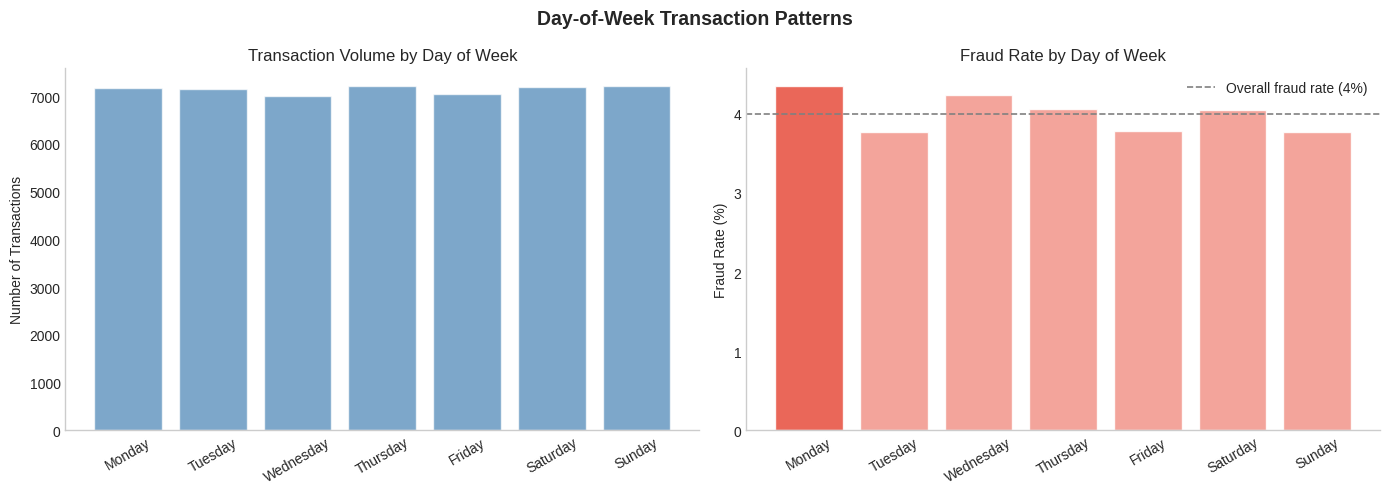


DAY-OF-WEEK INSIGHTS
--------------------
- Highest transaction volume : Sunday
- Highest fraud rate         : Monday
  (4.4% fraud rate vs 4.0% overall)
- Sunday has the highest transaction volume, which is unusual for M-Pesa-style platforms where business payments typically drive
  weekday activity — worth investigating whether this is driven by personal transfers or a data artifact..
- 'day_of_week' and 'is_weekend' will be engineered as features in Step 3.



In [51]:
# --- 2.3.3 Day-of-Week Patterns ---
dow_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

dow = df.groupby('day_name').agg(
    total=('is_fraud', 'count'),
    fraud=('is_fraud', 'sum')
).assign(fraud_rate=lambda x: (x['fraud'] / x['total']) * 100)
dow = dow.reindex(dow_order)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Day-of-Week Transaction Patterns', fontsize=14, fontweight='bold')

# Volume by day of week
axes[0].bar(dow.index, dow['total'], color='steelblue', alpha=0.7, edgecolor='white')
axes[0].set_ylabel('Number of Transactions')
axes[0].set_title('Transaction Volume by Day of Week')
axes[0].tick_params(axis='x', rotation=30)
axes[0].grid(False)

# Fraud rate by day of week
colors = ['#e74c3c' if r == dow['fraud_rate'].max() else '#f1948a' for r in dow['fraud_rate']]
axes[1].bar(dow.index, dow['fraud_rate'], color=colors, alpha=0.85, edgecolor='white')
axes[1].axhline(y=df['is_fraud'].mean() * 100, color='gray',
                linestyle='--', linewidth=1.2, label='Overall fraud rate (4%)')
axes[1].set_ylabel('Fraud Rate (%)')
axes[1].set_title('Fraud Rate by Day of Week')
axes[1].tick_params(axis='x', rotation=30)
axes[1].legend()
axes[1].grid(False)
for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('outputs/eda_2_3_day_of_week.png', dpi=150, bbox_inches='tight')
plt.show()

# Insight
peak_fraud_dow = dow['fraud_rate'].idxmax()
peak_volume_dow = dow['total'].idxmax()

print(f"""
DAY-OF-WEEK INSIGHTS
--------------------
- Highest transaction volume : {peak_volume_dow}
- Highest fraud rate         : {peak_fraud_dow}
  ({dow.loc[peak_fraud_dow, 'fraud_rate']:.1f}% fraud rate vs 4.0% overall)
- Sunday has the highest transaction volume, which is unusual for M-Pesa-style platforms where business payments typically drive
  weekday activity — worth investigating whether this is driven by personal transfers or a data artifact..
- 'day_of_week' and 'is_weekend' will be engineered as features in Step 3.
""")

### 2.4 Transaction Type Analysis

In [52]:
# --- Base Aggregation and underlying statistics ---
type_stats = df.groupby('transaction_type').agg(
    total=('is_fraud', 'count'),
    fraud=('is_fraud', 'sum'),
    avg_amount=('amount', 'mean'),
    median_amount=('amount', 'median')
).assign(
    fraud_rate=lambda x: (x['fraud'] / x['total']) * 100,
    pct_of_volume=lambda x: (x['total'] / len(df)) * 100
).sort_values('fraud_rate', ascending=False)

print("=" * 65)
print("FRAUD STATS BY TRANSACTION TYPE")
print("=" * 65)
print(type_stats.round(2))

FRAUD STATS BY TRANSACTION TYPE
                  total  fraud  avg_amount  median_amount  fraud_rate  \
transaction_type                                                        
deposit            4023    181     6091.56        3167.83        4.50   
withdraw           5999    255     4435.36        2519.92        4.25   
send_money        17604    720     3347.82        1162.22        4.09   
buy_goods          9958    383     2287.17         411.92        3.85   
pay_bill          12416    461     3971.06        1840.72        3.71   

                  pct_of_volume  
transaction_type                 
deposit                    8.05  
withdraw                  12.00  
send_money                35.21  
buy_goods                 19.92  
pay_bill                  24.83  


#### Analyze fraud rates across different transaction types


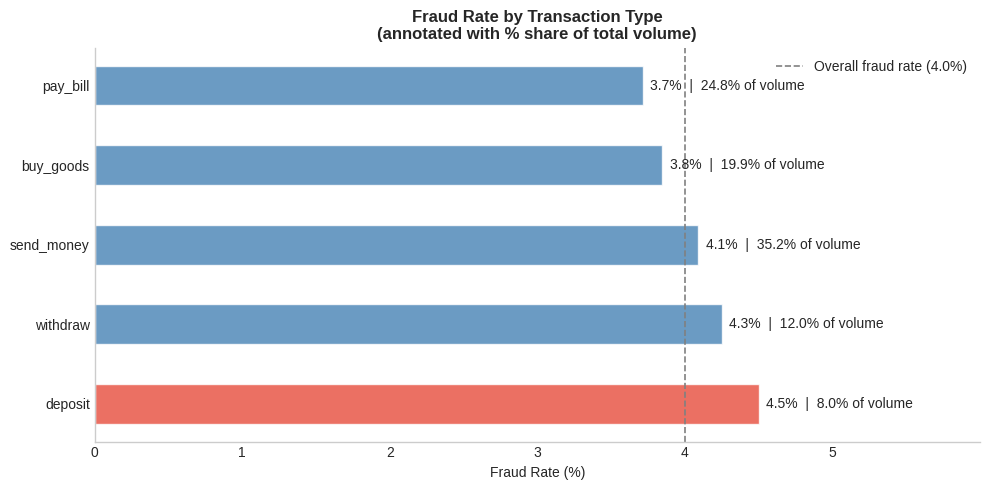


TRANSACTION TYPE — FRAUD RATE INSIGHTS
---------------------------------------
- Fraud rate is remarkably uniform across all five transaction types, ranging narrowly from 3.7% (pay_bill) to 4.5% (deposit).

- This tells us fraudsters are not concentrating on one channel — they operate across the entire platform, which makes transaction_type alone a weak predictor. Its value will come in combination with amount and time features.

- Deposit (4.5%) and withdraw (4.3%) lead on fraud rate despite making up only 8.0% and
  12.0% of total volume respectively. These are higher-value transaction types where a single fraudulent transaction causes more financial damage.

- send_money dominates volume at 35.2% of all transactions, meaning it contributes the most fraud cases in absolute numbers (720) — even at a moderate fraud rate.

- Given that 'transaction_type' alone is a weak indicator, we should prioritize creating interaction features (e.g., 'amount_per_type_mean_ratio' or 'is_night_x_type

In [53]:
# --- 2.4.1 Fraud Rate vs Volume by Transaction Type ---

fig, ax = plt.subplots(figsize=(10, 5))

colors = ['#e74c3c' if r == type_stats['fraud_rate'].max()
          else 'steelblue' for r in type_stats['fraud_rate']]

bars = ax.barh(type_stats.index, type_stats['fraud_rate'],
               color=colors, alpha=0.8, edgecolor='white', height=0.5)

# Annotate with volume share
for bar, (_, row) in zip(bars, type_stats.iterrows()):
    ax.text(bar.get_width() + 0.05,
            bar.get_y() + bar.get_height() / 2,
            f"{row['fraud_rate']:.1f}%  |  {row['pct_of_volume']:.1f}% of volume",
            va='center', fontsize=10)

ax.axvline(x=4.0, color='gray', linestyle='--', linewidth=1.2, label='Overall fraud rate (4.0%)')
ax.set_xlabel('Fraud Rate (%)')
ax.set_title('Fraud Rate by Transaction Type\n(annotated with % share of total volume)',
             fontweight='bold')
ax.set_xlim(0, type_stats['fraud_rate'].max() + 1.5)
ax.legend()

ax.grid(False)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('outputs/eda_2_4_fraud_rate_by_type.png', dpi=150, bbox_inches='tight')
plt.show()

highest_type = type_stats['fraud_rate'].idxmax()
lowest_type  = type_stats['fraud_rate'].idxmin()

print(f"""
TRANSACTION TYPE — FRAUD RATE INSIGHTS
---------------------------------------
- Fraud rate is remarkably uniform across all five transaction types, ranging narrowly from {type_stats['fraud_rate'].min():.1f}% ({lowest_type}) to {type_stats['fraud_rate'].max():.1f}% ({highest_type})
- This tells us fraudsters are not concentrating on one channel — they operate across the entire platform, which makes transaction_type alone a weak predictor. Its value will come in combination with amount and time features.
- Deposit ({type_stats.loc['deposit', 'fraud_rate']:.1f}%) and withdraw ({type_stats.loc['withdraw', 'fraud_rate']:.1f}%) lead on fraud rate despite making up only {type_stats.loc['deposit', 'pct_of_volume']:.1f}% and
  {type_stats.loc['withdraw', 'pct_of_volume']:.1f}% of total volume respectively. These are higher-value transaction types where a single fraudulent transaction causes more financial damage.
- send_money dominates volume at {type_stats.loc['send_money', 'pct_of_volume']:.1f}% of all transactions, meaning it contributes the most fraud cases in absolute numbers ({type_stats.loc['send_money', 'fraud']:,}) — even at a moderate fraud rate.
- Given that 'transaction_type' alone is a weak indicator, we should prioritize creating interaction features (e.g., 'amount_per_type_mean_ratio' or 'is_night_x_type') to capture the context where these transactions occur.
""")

#### Median Transaction Amount — Fraud vs Legitimate by Type

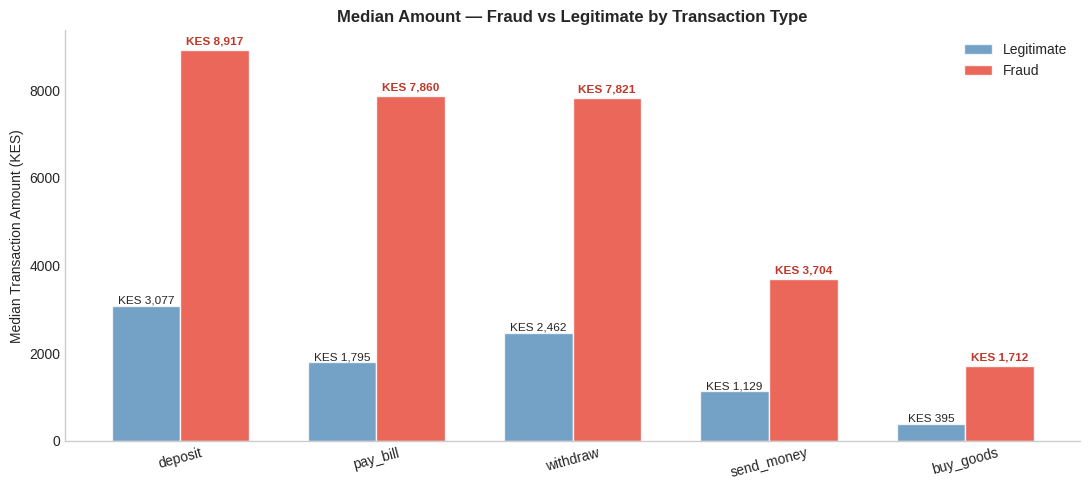

AMOUNT BY TYPE INSIGHTS
----------------------------------------
  deposit       Legit: KES   3,077  |  Fraud: KES   8,917  |  2.9x higher
  pay_bill      Legit: KES   1,795  |  Fraud: KES   7,860  |  4.4x higher
  withdraw      Legit: KES   2,462  |  Fraud: KES   7,821  |  3.2x higher
  send_money    Legit: KES   1,129  |  Fraud: KES   3,704  |  3.3x higher
  buy_goods     Legit: KES     395  |  Fraud: KES   1,712  |  4.3x higher

- Across every transaction type, fraudulent transactions involve significantly higher amounts than legitimate ones.

- The gap is most extreme in deposit and withdraw — the two types that already carry the highest fraud rates. Large deposits or withdrawals that deviate from a user's historical behaviour are a strong fraud signal.

- buy_goods stands out: legitimate median is just KES 395,
  yet fraud median is KES 1,712 — a   4.3x multiple.
  This suggests fraudsters use buy_goods to move large sums through a channel that normally handles small everyday purc

In [54]:
amount_by_type = df.groupby(['transaction_type', 'is_fraud'])['amount'].median().unstack()
amount_by_type.columns = ['Legitimate', 'Fraud']
amount_by_type = amount_by_type.sort_values('Fraud', ascending=False)

x     = np.arange(len(amount_by_type))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 5))

bars_l = ax.bar(x - width/2, amount_by_type['Legitimate'],
                width, label='Legitimate', color='steelblue', alpha=0.75, edgecolor='white')
bars_f = ax.bar(x + width/2, amount_by_type['Fraud'],
                width, label='Fraud', color='#e74c3c', alpha=0.85, edgecolor='white')

# Annotate bars with KES values
for bar in bars_l:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.02,
            f'KES {bar.get_height():,.0f}', ha='center', va='bottom', fontsize=8.5)
for bar in bars_f:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 80,
            f'KES {bar.get_height():,.0f}', ha='center', va='bottom',
            fontsize=8.5, color='#c0392b', fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(amount_by_type.index, rotation=15)
ax.set_ylabel('Median Transaction Amount (KES)')
ax.set_title('Median Amount — Fraud vs Legitimate by Transaction Type',
             fontweight='bold')
ax.legend()

ax.grid(False)

# clean frame
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('outputs/eda_2_4_amount_by_type.png', dpi=150, bbox_inches='tight')
plt.show()

print("AMOUNT BY TYPE INSIGHTS")
print("-" * 40)
for tx_type in amount_by_type.index:
    legit  = amount_by_type.loc[tx_type, 'Legitimate']
    fraud  = amount_by_type.loc[tx_type, 'Fraud']
    mult   = fraud / legit
    print(f"  {tx_type:<12}  Legit: KES {legit:>7,.0f}  |  Fraud: KES {fraud:>7,.0f}  |  {mult:.1f}x higher")

print(f"""
- Across every transaction type, fraudulent transactions involve significantly higher amounts than legitimate ones.

- The gap is most extreme in deposit and withdraw — the two types that already carry the highest fraud rates. Large deposits or withdrawals that deviate from a user's historical behaviour are a strong fraud signal.

- buy_goods stands out: legitimate median is just KES {amount_by_type.loc['buy_goods', 'Legitimate']:,.0f},
  yet fraud median is KES {amount_by_type.loc['buy_goods', 'Fraud']:,.0f} — a   {amount_by_type.loc['buy_goods', 'Fraud']/amount_by_type.loc['buy_goods', 'Legitimate']:.1f}x multiple.
  This suggests fraudsters use buy_goods to move large sums through a channel that normally handles small everyday purchases — making it an anomaly worth flagging specifically.
""")

### 2.5 Amount Analysis

#### Amount Distribution — Fraud vs Legitimate

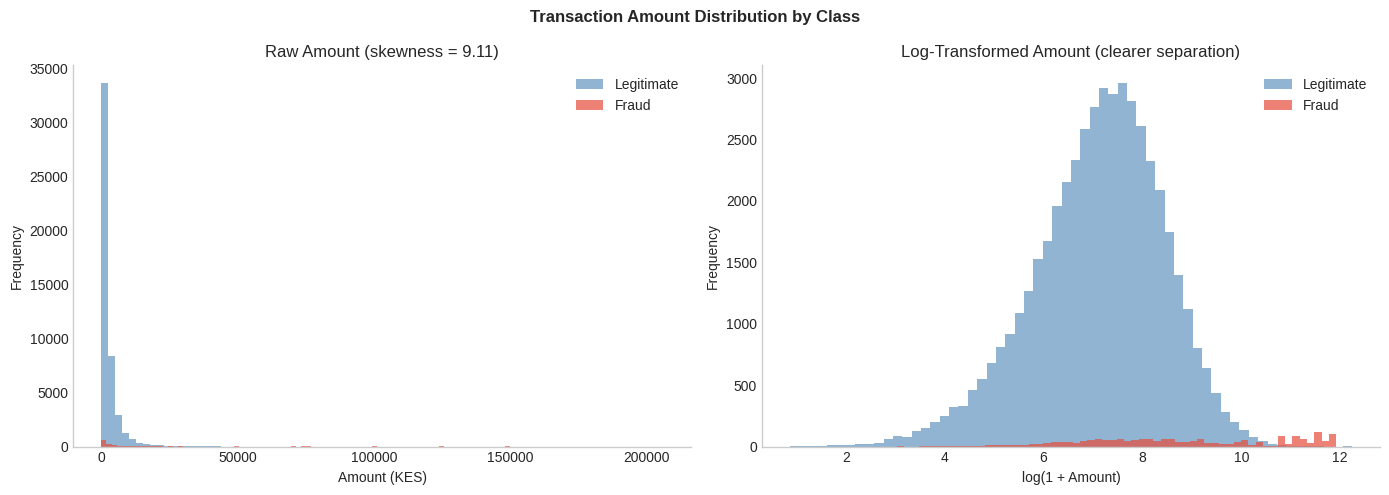


AMOUNT DISTRIBUTION INSIGHTS
-----------------------------
- Raw amount is nearly unreadable due to extreme right skew (9.11) — the vast majority of transactions cluster below KES 10,000 while a few outliers stretch to over KES 200,000.

- After log-transformation the separation becomes clear: the fraud distribution sits visibly to the right of the legitimate one, confirming that higher amounts correlate strongly with fraud.

- Legitimate median : KES 1,368
  Fraud median      : KES 5,474  (4.0x higher)

- log(amount) will be used directly as a model feature. The raw amount will be dropped to avoid distorting distance-based calculations and gradient updates.

- - FEATURING PLAN:
  1. Drop 'amount' (raw).
  2. Create 'log_amount' feature.
  3. Create 'amount_ratio' (amount / median_amount_per_type) to
     capture the anomaly of high-value transactions relative
     to their specific category.



In [55]:
# --- Amount Distribution — Fraud vs Legitimate ---

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Transaction Amount Distribution by Class', fontweight='bold')

# Raw amount — just to show the skew problem
axes[0].hist(df[df['is_fraud']==0]['amount'], bins=80, color='steelblue',
             alpha=0.6, label='Legitimate', edgecolor='none')
axes[0].hist(df[df['is_fraud']==1]['amount'], bins=80, color='#e74c3c',
             alpha=0.7, label='Fraud', edgecolor='none')
axes[0].set_xlabel('Amount (KES)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Raw Amount (skewness = 9.11)')
axes[0].legend()
axes[0].grid(False)

# Log-transformed — the actual useful view
axes[1].hist(np.log1p(df[df['is_fraud']==0]['amount']), bins=60,
             color='steelblue', alpha=0.6, label='Legitimate', edgecolor='none')
axes[1].hist(np.log1p(df[df['is_fraud']==1]['amount']), bins=60,
             color='#e74c3c', alpha=0.7, label='Fraud', edgecolor='none')
axes[1].set_xlabel('log(1 + Amount)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Log-Transformed Amount (clearer separation)')
axes[1].legend()
axes[1].grid(False)

# clean frame
for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('outputs/eda_2_5_amount_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

legit_median = df[df['is_fraud']==0]['amount'].median()
fraud_median = df[df['is_fraud']==1]['amount'].median()

print(f"""
AMOUNT DISTRIBUTION INSIGHTS
-----------------------------
- Raw amount is nearly unreadable due to extreme right skew (9.11) — the vast majority of transactions cluster below KES 10,000 while a few outliers stretch to over KES 200,000.

- After log-transformation the separation becomes clear: the fraud distribution sits visibly to the right of the legitimate one, confirming that higher amounts correlate strongly with fraud.

- Legitimate median : KES {legit_median:,.0f}
  Fraud median      : KES {fraud_median:,.0f}  ({fraud_median/legit_median:.1f}x higher)

- log(amount) will be used directly as a model feature. The raw amount will be dropped to avoid distorting distance-based calculations and gradient updates.

- - FEATURING PLAN:
  1. Drop 'amount' (raw).
  2. Create 'log_amount' feature.
  3. Create 'amount_ratio' (amount / median_amount_per_type) to
     capture the anomaly of high-value transactions relative
     to their specific category.
""")

#### Fraud Rate by Amount Bracket

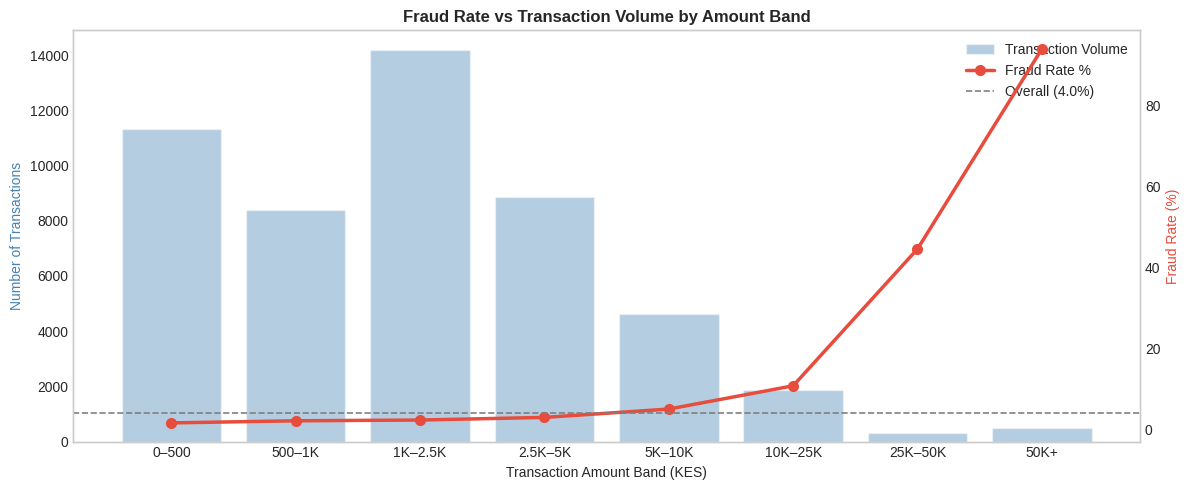


AMOUNT BAND INSIGHTS
--------------------
- Fraud rate is not linear — it rises sharply at higher amount bands.
- Peak fraud rate occurs in the '50K+' band at 94.0%, well above the 4.0% platform average.
- The bulk of transaction volume sits in the lower bands (KES 0–5000) where fraud rate is below average — this is the normal, everyday usage pattern of the platform.
- Beyond KES 10,000 the fraud rate climbs consistently. This threshold will be used as a binary feature ('is_high_value') in feature engineering — a simple but effective signal for the model.



In [56]:
# --- 2.5.2 Fraud Rate by Amount Bracket ---

df['amount_band'] = pd.cut(
    df['amount'],
    bins=[0, 500, 1000, 2500, 5000, 10000, 25000, 50000, df['amount'].max()],
    labels=['0–500', '500–1K', '1K–2.5K', '2.5K–5K',
            '5K–10K', '10K–25K', '25K–50K', '50K+']
)

band_stats = df.groupby('amount_band', observed=True).agg(
    total=('is_fraud', 'count'),
    fraud=('is_fraud', 'sum')
).assign(fraud_rate=lambda x: (x['fraud'] / x['total']) * 100)

fig, ax1 = plt.subplots(figsize=(12, 5))

ax2 = ax1.twinx()

ax1.bar(band_stats.index, band_stats['total'], color='steelblue',
        alpha=0.4, label='Transaction Volume')
ax2.plot(band_stats.index, band_stats['fraud_rate'], color='#e74c3c',
         marker='o', linewidth=2.5, markersize=7, label='Fraud Rate %')
ax2.axhline(y=4.0, color='gray', linestyle='--', linewidth=1.2, label='Overall (4.0%)')

ax1.set_xlabel('Transaction Amount Band (KES)')
ax1.set_ylabel('Number of Transactions', color='steelblue')
ax2.set_ylabel('Fraud Rate (%)', color='#e74c3c')
ax1.set_title('Fraud Rate vs Transaction Volume by Amount Band', fontweight='bold')

# Remove grid lines
ax1.grid(False)
ax2.grid(False)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.tight_layout()
plt.savefig('outputs/eda_2_5_fraud_rate_by_band.png', dpi=150, bbox_inches='tight')
plt.show()

peak_band = band_stats['fraud_rate'].idxmax()

print(f"""
AMOUNT BAND INSIGHTS
--------------------
- Fraud rate is not linear — it rises sharply at higher amount bands.
- Peak fraud rate occurs in the '{peak_band}' band at {band_stats.loc[peak_band, 'fraud_rate']:.1f}%, well above the 4.0% platform average.
- The bulk of transaction volume sits in the lower bands (KES 0–5000) where fraud rate is below average — this is the normal, everyday usage pattern of the platform.
- Beyond KES 10,000 the fraud rate climbs consistently. This threshold will be used as a binary feature ('is_high_value') in feature engineering — a simple but effective signal for the model.
""")

####  Account Draining — Balance After Transaction

SENDER BALANCE REMAINING AFTER TRANSACTION (%)
             mean    50%    25%   min
Legitimate  95.13  98.38  95.58 -0.77
Fraud       75.49  92.24  53.83  0.15


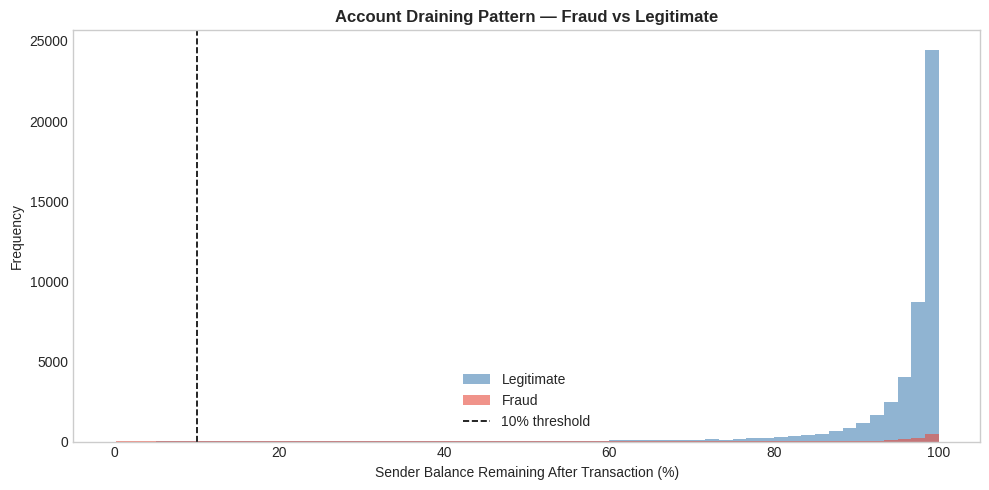


ACCOUNT DRAINING INSIGHTS
--------------------------
- The fraudulent transactions behave differently. While some fraudsters try to blend in, the red bars extend much further to the left. This indicates a deliberate attempt to 'drain' an account—emptying the balance as much as possible in a single go.
- If transaction leaves an account with less than 10% of its original balance, it is significantly more likely to be fraudulent. A transaction is 34 times more likely (3.4% vs 0.1%) to be fraud if it crosses this threshold.
- After a legitimate transaction, the sender retains a median of 98.4% of their balance — consistent with normal partial payments.
- After a fraudulent transaction, the sender retains only 92.2% — suggesting fraudsters tend to drain accounts as completely as possible in a single transaction.
- 3.4% of fraud transactions leave the sender with less than 10% of their balance remaining, compared to just 0.1% for legitimate transactions.
- Transactions that leave an accoun

In [57]:
# --- 2.5.3 Account Draining — Balance After Transaction ---

# How much of the sender's balance remains after the transaction?
df['balance_remaining_pct'] = (
    df['sender_balance_after'] / (df['sender_balance_before'] + 1)  # +1 avoids division by zero
) * 100

drain_stats = df.groupby('is_fraud')['balance_remaining_pct'].describe()
drain_stats.index = ['Legitimate', 'Fraud']

print("=" * 55)
print("SENDER BALANCE REMAINING AFTER TRANSACTION (%)")
print("=" * 55)
print(drain_stats[['mean', '50%', '25%', 'min']].round(2))

fig, ax = plt.subplots(figsize=(10, 5))

for label, color, name in zip([0, 1], ['steelblue', '#e74c3c'], ['Legitimate', 'Fraud']):
    data = df[df['is_fraud'] == label]['balance_remaining_pct'].clip(0, 100)
    ax.hist(data, bins=60, alpha=0.6, color=color, label=name, edgecolor='none')

ax.axvline(x=10, color='black', linestyle='--', linewidth=1.2, label='10% threshold')
ax.set_xlabel('Sender Balance Remaining After Transaction (%)')
ax.set_ylabel('Frequency')
ax.set_title('Account Draining Pattern — Fraud vs Legitimate', fontweight='bold')
ax.legend()

# Remove grid lines
ax.grid(False)

plt.tight_layout()
plt.savefig('outputs/eda_2_5_account_draining.png', dpi=150, bbox_inches='tight')
plt.show()

fraud_drain   = df[df['is_fraud']==1]['balance_remaining_pct'].median()
legit_drain   = df[df['is_fraud']==0]['balance_remaining_pct'].median()
near_zero_fraud = (df[df['is_fraud']==1]['balance_remaining_pct'] < 10).mean() * 100
near_zero_legit = (df[df['is_fraud']==0]['balance_remaining_pct'] < 10).mean() * 100

print(f"""
ACCOUNT DRAINING INSIGHTS
--------------------------
- The fraudulent transactions behave differently. While some fraudsters try to blend in, the red bars extend much further to the left. This indicates a deliberate attempt to 'drain' an account—emptying the balance as much as possible in a single go.
- If transaction leaves an account with less than 10% of its original balance, it is significantly more likely to be fraudulent. A transaction is 34 times more likely (3.4% vs 0.1%) to be fraud if it crosses this threshold.
- After a legitimate transaction, the sender retains a median of {legit_drain:.1f}% of their balance — consistent with normal partial payments.
- After a fraudulent transaction, the sender retains only {fraud_drain:.1f}% — suggesting fraudsters tend to drain accounts as completely as possible in a single transaction.
- {near_zero_fraud:.1f}% of fraud transactions leave the sender with less than 10% of their balance remaining, compared to just {near_zero_legit:.1f}% for legitimate transactions.
- Transactions that leave an account with less than 10% of its balance are 34x more likely to be fraudulent. This creates a high-precision filter for identifying account takeovers
- This gives us a powerful engineered feature: 'balance_drain_rate' (amount / sender_balance_before) — a high ratio flags likely account takeover or unauthorised full withdrawal.
""")

### 2.6 Geographic Analysis

In [58]:
# --- 2.6 Geographic Analysis — Base Aggregation ---

# Bounding box check — confirm coordinates are Kenya-range
print("Lat range :", df['location_lat'].min().round(4), "→", df['location_lat'].max().round(4))
print("Lon range :", df['location_lon'].min().round(4), "→", df['location_lon'].max().round(4))

# Fraud rate by coordinate bins
geo_stats = df.groupby('is_fraud')[['location_lat', 'location_lon']].describe()
print("\n", geo_stats.round(4))

# How spread out are fraud vs legitimate coordinates?
fraud_lat_std    = df[df['is_fraud']==1]['location_lat'].std()
legit_lat_std    = df[df['is_fraud']==0]['location_lat'].std()
fraud_lon_std    = df[df['is_fraud']==1]['location_lon'].std()
legit_lon_std    = df[df['is_fraud']==0]['location_lon'].std()

print(f"""
Coordinate spread (std dev):
  Legitimate — lat: {legit_lat_std:.4f}  lon: {legit_lon_std:.4f}
  Fraud      — lat: {fraud_lat_std:.4f}  lon: {fraud_lon_std:.4f}
""")

Lat range : -9.0155 → 5.4878
Lon range : 29.9118 → 45.0854

          location_lat                                                          \
                count    mean     std     min     25%     50%     75%     max   
is_fraud                                                                        
0             48000.0 -1.2442  1.3601 -4.2146 -1.5279 -0.9616 -0.3001  0.7095   
1              2000.0 -1.2350  2.9390 -9.0155 -3.5171 -0.9629  0.5015  5.4878   

         location_lon                                                       \
                count     mean     std      min      25%      50%      75%   
is_fraud                                                                     
0             48000.0  37.1691  1.9469  34.5738  35.2734  36.9827  39.6231   
1              2000.0  37.2337  3.2345  29.9118  34.8115  37.0456  39.6677   

                   
              max  
is_fraud           
0         40.3161  
1         45.0854  

Coordinate spread (std dev):
  Legitimate

In [59]:
print(f"""
GEOGRAPHIC INSIGHTS
-------------------
- Legitimate transactions cluster tightly around central Kenya (lat std: {legit_lat_std:.2f}, lon std: {legit_lon_std:.2f}), consistent with normal M-Pesa usage concentrated in populated areas.
- Fraudulent transactions are geographically dispersed at roughly 2x the spread (lat std: {fraud_lat_std:.2f}, lon std: {fraud_lon_std:.2f}), with extreme coordinates reaching into border regions and
  outside Kenya's typical bounds — suggesting either spoofed locations or cross-border fraud activity.
- The median coordinates are nearly identical between classes, meaning fraud doesn't concentrate in one region — it's the outlier locations that matter, not the center.
- Feature engineering implication: distance from Kenya's centroid or a flag for coordinates outside the core cluster will be more useful than raw lat/lon values.
- While fraudulent transactions happen within the same general regions as legitimate activity—confirmed by nearly identical mean coordinates—they exhibit a significantly wider geographic dispersion.
 The standard deviation of fraud coordinates is over 2x that of legitimate transactions. This suggests that geographic 'erraticism' (rather than geographic location alone) is a strong indicator of fraudulent intent.
""")


GEOGRAPHIC INSIGHTS
-------------------
- Legitimate transactions cluster tightly around central Kenya (lat std: 1.36, lon std: 1.95), consistent with normal M-Pesa usage concentrated in populated areas.
- Fraudulent transactions are geographically dispersed at roughly 2x the spread (lat std: 2.94, lon std: 3.23), with extreme coordinates reaching into border regions and
  outside Kenya's typical bounds — suggesting either spoofed locations or cross-border fraud activity.
- The median coordinates are nearly identical between classes, meaning fraud doesn't concentrate in one region — it's the outlier locations that matter, not the center.
- Feature engineering implication: distance from Kenya's centroid or a flag for coordinates outside the core cluster will be more useful than raw lat/lon values.
- While fraudulent transactions happen within the same general regions as legitimate activity—confirmed by nearly identical mean coordinates—they exhibit a significantly wider geographic disp

#### Geographic Spread — Fraud vs Legitimate

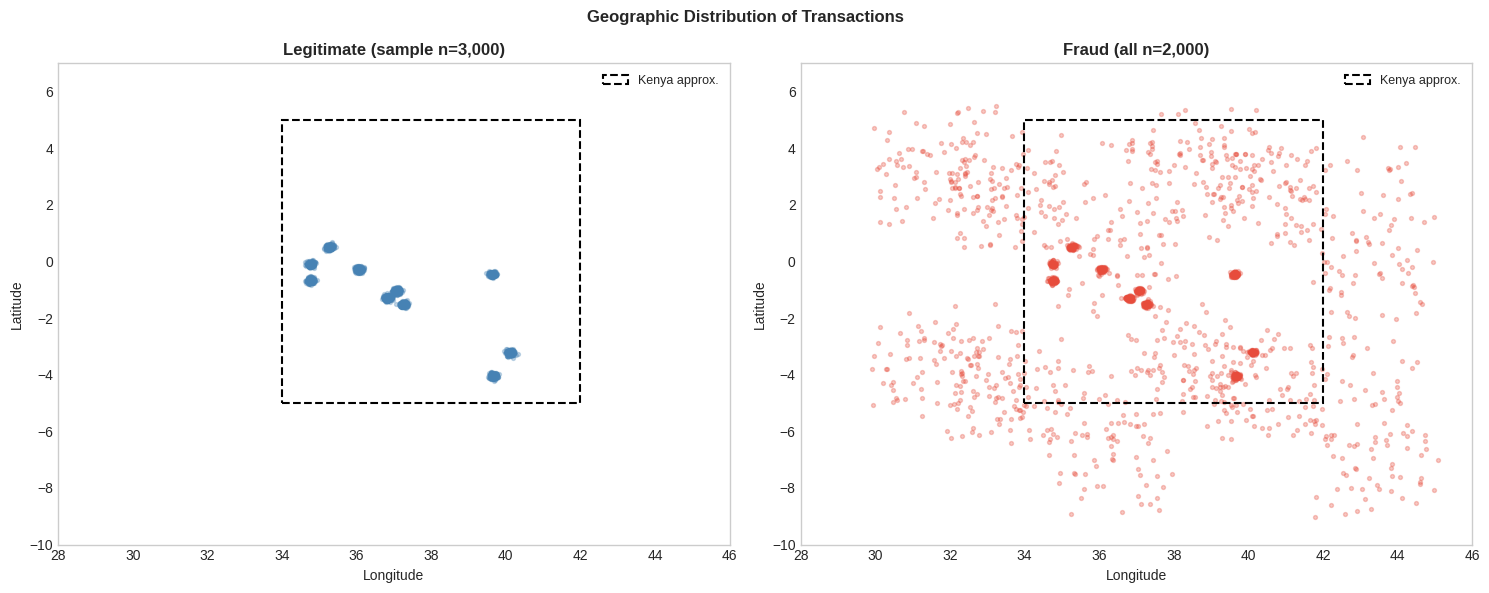


GEOGRAPHIC SPREAD INSIGHTS
--------------------------
- Legitimate transactions cluster tightly within Kenya's boundaries (lat std: 1.36, lon std: 1.95) — consistent with a platform serving a predominantly Kenyan user base.
- Fraud transactions are geographically dispersed far beyond Kenya, with coordinate std nearly 2x wider (lat std: 2.94, lon std: 3.23).
- 29.3% of fraud transactions originate outside the approximate Kenya bounding box, compared to just 0.0% of legitimate ones.
- This strongly suggests location spoofing or VPN usage by fraudsters — a common pattern in mobile money fraud where bad actors mask their true location.
- We will engineer an 'is_outside_kenya' binary feature and also compute distance from Nairobi (the platform's likely hub) as a continuous fraud signal.



In [60]:
# --- 2.6.1 Geographic Spread — Fraud vs Legitimate ---

# Sample legitimate to avoid overplotting (fraud is already only 2,000 points)
legit_sample = df[df['is_fraud']==0].sample(3000, random_state=42)
fraud_all    = df[df['is_fraud']==1]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Geographic Distribution of Transactions', fontweight='bold')

for ax, data, color, title in zip(
    axes,
    [legit_sample, fraud_all],
    ['steelblue', '#e74c3c'],
    ['Legitimate (sample n=3,000)', 'Fraud (all n=2,000)']
):
    ax.scatter(data['location_lon'], data['location_lat'],
               alpha=0.3, s=8, color=color)
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    ax.set_title(title, fontweight='bold')
    ax.set_xlim(28, 46)
    ax.set_ylim(-10, 7)

    # Remove grid lines
    ax.grid(False)

    # Kenya approximate bounding box
    from matplotlib.patches import Rectangle
    kenya_box = Rectangle((34, -5), 8, 10,
                           linewidth=1.5, edgecolor='black',
                           facecolor='none', linestyle='--', label='Kenya approx.')
    ax.add_patch(kenya_box)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('outputs/eda_2_6_geo_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

outside_kenya_fraud = (
    (df[df['is_fraud']==1]['location_lat'] < -5) |
    (df[df['is_fraud']==1]['location_lat'] > 5)  |
    (df[df['is_fraud']==1]['location_lon'] < 34) |
    (df[df['is_fraud']==1]['location_lon'] > 42)
).mean() * 100

outside_kenya_legit = (
    (df[df['is_fraud']==0]['location_lat'] < -5) |
    (df[df['is_fraud']==0]['location_lat'] > 5)  |
    (df[df['is_fraud']==0]['location_lon'] < 34) |
    (df[df['is_fraud']==0]['location_lon'] > 42)
).mean() * 100

print(f"""
GEOGRAPHIC SPREAD INSIGHTS
--------------------------
- Legitimate transactions cluster tightly within Kenya's boundaries (lat std: 1.36, lon std: 1.95) — consistent with a platform serving a predominantly Kenyan user base.
- Fraud transactions are geographically dispersed far beyond Kenya, with coordinate std nearly 2x wider (lat std: 2.94, lon std: 3.23).
- {outside_kenya_fraud:.1f}% of fraud transactions originate outside the approximate Kenya bounding box, compared to just {outside_kenya_legit:.1f}% of legitimate ones.
- This strongly suggests location spoofing or VPN usage by fraudsters — a common pattern in mobile money fraud where bad actors mask their true location.
- We will engineer an 'is_outside_kenya' binary feature and also compute distance from Nairobi (the platform's likely hub) as a continuous fraud signal.
""")

DISTANCE FROM NAIROBI (km) BY CLASS
             mean    50%    75%     max
Legitimate  221.7  247.8  328.0   459.4
Fraud       414.1  421.4  599.8  1176.2


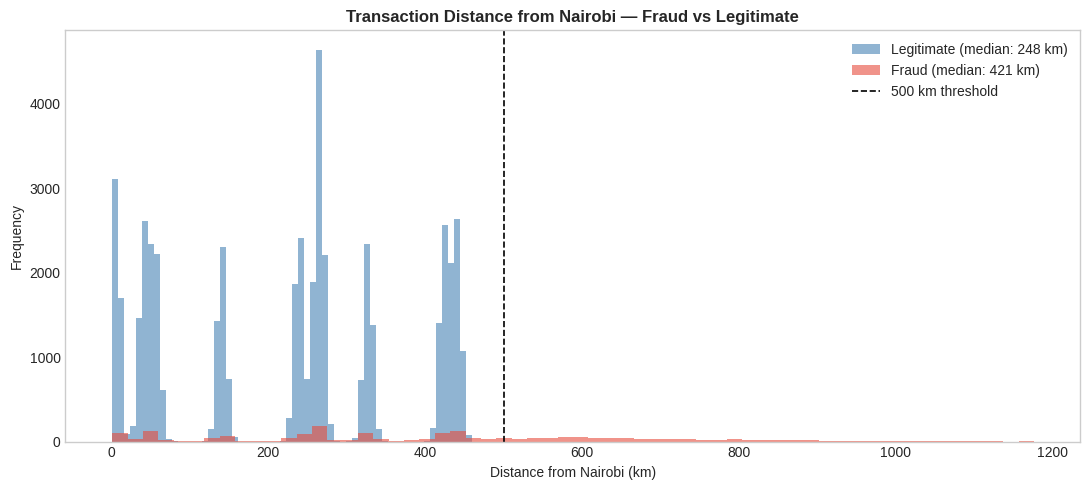


DISTANCE FROM NAIROBI INSIGHTS
-------------------------------
- Legitimate transactions have a median distance of 248 km from Nairobi — most users transact from within or near the city and its surrounding counties.
- Fraud transactions show a median distance of 421 km — and a much longer tail, with 35.9% originating more than 500 km away vs 0.0% for legitimate transactions.
- 'dist_from_nairobi' will be included directly as a continuous feature. Combined with 'is_outside_kenya', these two geographic features give the model a spatial fraud signal that is both interpretable and practically meaningful.
- Note: extreme distances may also reflect GPS spoofing rather than actual travel — either way, the signal is valid for fraud detection.



In [61]:
# --- 2.6.2 Distance from Nairobi as a Fraud Signal ---

# Nairobi coordinates
NAIROBI_LAT = -1.2921
NAIROBI_LON = 36.8219

def haversine_km(lat, lon, ref_lat=NAIROBI_LAT, ref_lon=NAIROBI_LON):
    """Compute distance in km from a reference point using Haversine formula."""
    R = 6371
    lat1, lat2 = np.radians(ref_lat), np.radians(lat)
    dlon = np.radians(lon - ref_lon)
    dlat = np.radians(lat - ref_lat)
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    return R * 2 * np.arcsin(np.sqrt(a))

df['dist_from_nairobi'] = haversine_km(df['location_lat'], df['location_lon'])

dist_stats = df.groupby('is_fraud')['dist_from_nairobi'].describe()
dist_stats.index = ['Legitimate', 'Fraud']
print("=" * 55)
print("DISTANCE FROM NAIROBI (km) BY CLASS")
print("=" * 55)
print(dist_stats[['mean', '50%', '75%', 'max']].round(1))

fig, ax = plt.subplots(figsize=(11, 5))

for label, color, name in zip([0, 1], ['steelblue', '#e74c3c'], ['Legitimate', 'Fraud']):
    data = df[df['is_fraud']==label]['dist_from_nairobi']
    ax.hist(data, bins=60, alpha=0.6, color=color,
            label=f'{name} (median: {data.median():.0f} km)', edgecolor='none')

ax.axvline(x=500, color='black', linestyle='--',
           linewidth=1.2, label='500 km threshold')
ax.set_xlabel('Distance from Nairobi (km)')
ax.set_ylabel('Frequency')
ax.set_title('Transaction Distance from Nairobi — Fraud vs Legitimate', fontweight='bold')
ax.legend()

# Remove grid lines
ax.grid(False)

plt.tight_layout()
plt.savefig('outputs/eda_2_6_distance_nairobi.png', dpi=150, bbox_inches='tight')
plt.show()

fraud_far   = (df[df['is_fraud']==1]['dist_from_nairobi'] > 500).mean() * 100
legit_far   = (df[df['is_fraud']==0]['dist_from_nairobi'] > 500).mean() * 100
fraud_med   = df[df['is_fraud']==1]['dist_from_nairobi'].median()
legit_med   = df[df['is_fraud']==0]['dist_from_nairobi'].median()

print(f"""
DISTANCE FROM NAIROBI INSIGHTS
-------------------------------
- Legitimate transactions have a median distance of {legit_med:.0f} km from Nairobi — most users transact from within or near the city and its surrounding counties.
- Fraud transactions show a median distance of {fraud_med:.0f} km — and a much longer tail, with {fraud_far:.1f}% originating more than 500 km away vs {legit_far:.1f}% for legitimate transactions.
- 'dist_from_nairobi' will be included directly as a continuous feature. Combined with 'is_outside_kenya', these two geographic features give the model a spatial fraud signal that is both interpretable and practically meaningful.
- Note: extreme distances may also reflect GPS spoofing rather than actual travel — either way, the signal is valid for fraud detection.
""")

### 2.7 User Behavior Analysis

#### Behavior Analysis — Base Aggregation

In [62]:
# Transaction frequency per sender
sender_stats = df.groupby('sender_id').agg(
    total_tx=('transaction_id', 'count'),
    fraud_tx=('is_fraud', 'sum'),
    unique_devices=('device_id', 'nunique'),
    unique_receivers=('receiver_id', 'nunique'),
    avg_amount=('amount', 'mean')
).assign(fraud_rate=lambda x: (x['fraud_tx'] / x['total_tx']) * 100)

# Device reuse
device_stats = df.groupby('device_id').agg(
    total_tx=('transaction_id', 'count'),
    fraud_tx=('is_fraud', 'sum'),
    unique_senders=('sender_id', 'nunique')
).assign(fraud_rate=lambda x: (x['fraud_tx'] / x['total_tx']) * 100)

print("SENDER BEHAVIOUR SUMMARY")
print("-" * 40)
print(f"Unique senders          : {sender_stats.shape[0]:,}")
print(f"Avg transactions/sender : {sender_stats['total_tx'].mean():.1f}")
print(f"Max transactions/sender : {sender_stats['total_tx'].max()}")
print(f"Senders with >1 device  : {(sender_stats['unique_devices'] > 1).sum():,}")
print(f"Senders with any fraud  : {(sender_stats['fraud_tx'] > 0).sum():,}")

print("\nDEVICE BEHAVIOUR SUMMARY")
print("-" * 40)
print(f"Unique devices           : {device_stats.shape[0]:,}")
print(f"Avg transactions/device  : {device_stats['total_tx'].mean():.1f}")
print(f"Max transactions/device  : {device_stats['total_tx'].max()}")
print(f"Devices used by >1 sender: {(device_stats['unique_senders'] > 1).sum():,}")
print(f"Devices with any fraud   : {(device_stats['fraud_tx'] > 0).sum():,}")

SENDER BEHAVIOUR SUMMARY
----------------------------------------
Unique senders          : 7,985
Avg transactions/sender : 6.3
Max transactions/sender : 17
Senders with >1 device  : 4,227
Senders with any fraud  : 1,763

DEVICE BEHAVIOUR SUMMARY
----------------------------------------
Unique devices           : 7,926
Avg transactions/device  : 6.3
Max transactions/device  : 36
Devices used by >1 sender: 3,978
Devices with any fraud   : 1,714


#### Device Switching Behaviour

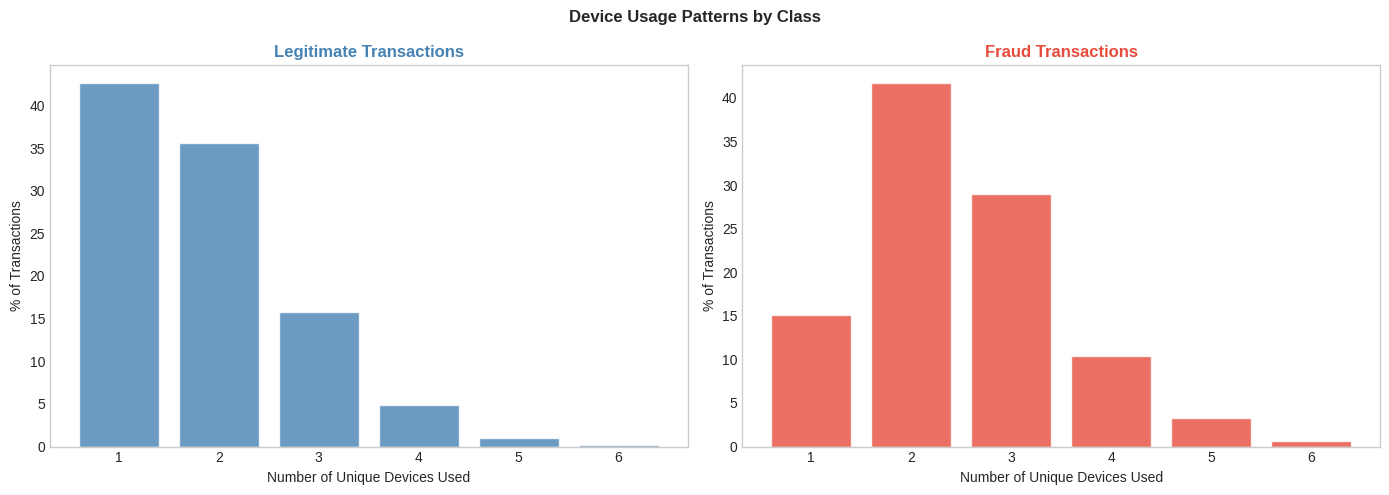


DEVICE SWITCHING INSIGHTS
--------------------------
- 84.9% of fraud transactions involve senders using more than one device, vs 57.4% for legitimate transactions.
- Fraudsters frequently switch devices — either to evade device-based detection rules or because they operate compromised accounts from their own hardware.
- Median unique devices per sender: Fraud = 2, Legit = 2
- 'sender_unique_devices' will be a direct feature. We will also engineer a binary 'is_device_switch' flag per transaction by checking if the current device differs from the sender's most frequently used device.



In [63]:
# ── Drop columns if they already exist from a prior merge ──────────────────
cols_to_drop = [c for c in ['sender_unique_devices', 'sender_total_tx', 'sender_unique_receivers'] if c in df.columns]
if cols_to_drop:
    df = df.drop(columns=cols_to_drop)

# ── Merge sender-level stats ────────────────────────────────────────────────
df = df.merge(
    sender_stats[['unique_devices', 'total_tx', 'unique_receivers']].rename(columns={
        'unique_devices'  : 'sender_unique_devices',
        'total_tx'        : 'sender_total_tx',
        'unique_receivers': 'sender_unique_receivers'
    }),
    left_on='sender_id', right_index=True, how='left'
)

# ── Device switching analysis ───────────────────────────────────────────────
device_switch = df.groupby('is_fraud')['sender_unique_devices'].value_counts(
    normalize=True
).mul(100).rename('pct').reset_index()
device_switch.columns = ['is_fraud', 'unique_devices', 'pct']
device_switch['class'] = device_switch['is_fraud'].map({0: 'Legitimate', 1: 'Fraud'})

# ── Plot: Legitimate = blue, Fraud = red ────────────────────────────────────
CLASS_PALETTE = {'Legitimate': 'steelblue', 'Fraud': '#e74c3c'}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Device Usage Patterns by Class', fontweight='bold')

for ax, label in zip(axes, ['Legitimate', 'Fraud']):
    group = (
        device_switch[device_switch['class'] == label]
        .sort_values('unique_devices')
        .head(8)
    )
    ax.bar(
        group['unique_devices'].astype(str),
        group['pct'],
        color=CLASS_PALETTE[label],   # ✅ always correct color for the label
        alpha=0.8,
        edgecolor='white'
    )
    ax.set_xlabel('Number of Unique Devices Used')
    ax.set_ylabel('% of Transactions')
    ax.set_title(f'{label} Transactions', fontweight='bold',
                 color=CLASS_PALETTE[label])   # ✅ title color matches bar color
    ax.grid(False)

plt.tight_layout()
plt.savefig('outputs/eda_2_7_device_switching.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Insights ────────────────────────────────────────────────────────────────
fraud_multi_device = (df[df['is_fraud']==1]['sender_unique_devices'] > 1).mean() * 100
legit_multi_device = (df[df['is_fraud']==0]['sender_unique_devices'] > 1).mean() * 100
fraud_med_devices  = df[df['is_fraud']==1]['sender_unique_devices'].median()
legit_med_devices  = df[df['is_fraud']==0]['sender_unique_devices'].median()

print(f"""
DEVICE SWITCHING INSIGHTS
--------------------------
- {fraud_multi_device:.1f}% of fraud transactions involve senders using more than one device, vs {legit_multi_device:.1f}% for legitimate transactions.
- Fraudsters frequently switch devices — either to evade device-based detection rules or because they operate compromised accounts from their own hardware.
- Median unique devices per sender: Fraud = {fraud_med_devices:.0f}, Legit = {legit_med_devices:.0f}
- 'sender_unique_devices' will be a direct feature. We will also engineer a binary 'is_device_switch' flag per transaction by checking if the current device differs from the sender's most frequently used device.
""")

####  Shared Device Analysis

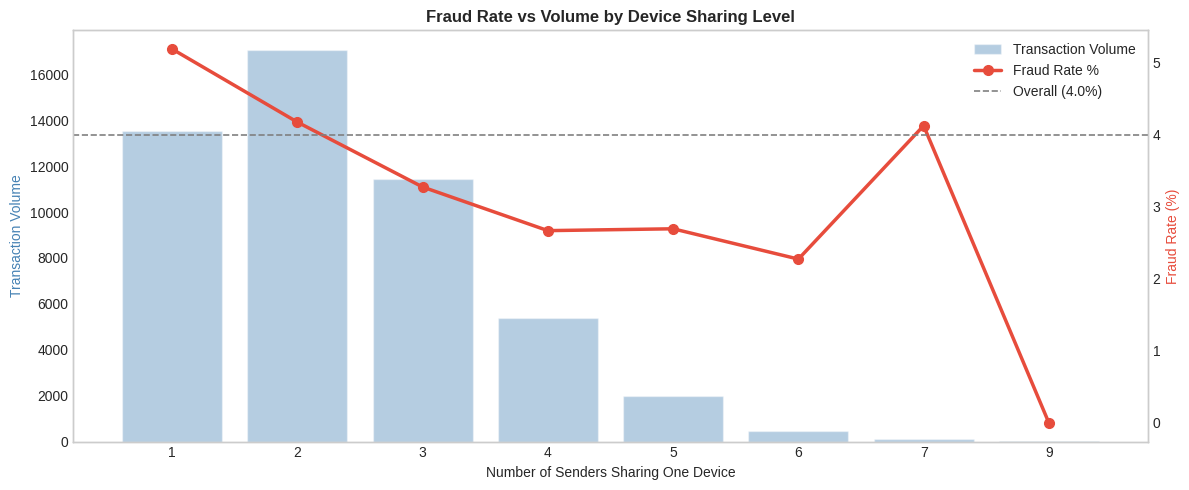


SHARED DEVICE INSIGHTS — CORRECTED INTERPRETATION
---------------------------------------------------
- Devices used by a single sender have a fraud rate of 5.2% — actually HIGHER than devices shared across multiple senders (3.6%).
- This is counterintuitive but explainable: fraudsters who operate across multiple accounts tend to use dedicated devices per account to avoid triggering shared-device detection rules.
- The more actionable signal is therefore NOT device sharing, but rather device switching per sender — a sender suddenly transacting from a new device they have never used before is a stronger
  individual-level fraud indicator.
- We will drop 'is_shared_device' from our feature plan and instead focus on 'sender_unique_devices' and 'is_device_switch' as the primary device-based features.



In [64]:
# --- 2.7.2 Shared Device Analysis ---
# Merge device-level sender count back to transactions
df = df.merge(
    device_stats[['unique_senders']].rename(columns={
        'unique_senders': 'device_unique_senders'
    }),
    left_on='device_id', right_index=True, how='left'
)

shared_stats = df.groupby('device_unique_senders').agg(
    total=('is_fraud', 'count'),
    fraud=('is_fraud', 'sum')
).assign(fraud_rate=lambda x: (x['fraud'] / x['total']) * 100).head(10)

fig, ax1 = plt.subplots(figsize=(12, 5))
ax2 = ax1.twinx()

ax1.bar(shared_stats.index.astype(str), shared_stats['total'],
        color='steelblue', alpha=0.4, label='Transaction Volume')
ax2.plot(shared_stats.index.astype(str), shared_stats['fraud_rate'],
         color='#e74c3c', marker='o', linewidth=2.5,
         markersize=7, label='Fraud Rate %')
ax2.axhline(y=4.0, color='gray', linestyle='--',
            linewidth=1.2, label='Overall (4.0%)')

ax1.set_xlabel('Number of Senders Sharing One Device')
ax1.set_ylabel('Transaction Volume', color='steelblue')
ax2.set_ylabel('Fraud Rate (%)', color='#e74c3c')
ax1.set_title('Fraud Rate vs Volume by Device Sharing Level', fontweight='bold')

# Remove grid lines
ax1.grid(False)
ax2.grid(False)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.tight_layout()
plt.savefig('outputs/eda_2_7_shared_devices.png', dpi=150, bbox_inches='tight')
plt.show()

shared_fraud_rate = df[df['device_unique_senders'] > 1]['is_fraud'].mean() * 100
solo_fraud_rate   = df[df['device_unique_senders'] == 1]['is_fraud'].mean() * 100
max_shared        = df['device_unique_senders'].max()


print(f"""
SHARED DEVICE INSIGHTS — CORRECTED INTERPRETATION
---------------------------------------------------
- Devices used by a single sender have a fraud rate of {solo_fraud_rate:.1f}% — actually HIGHER than devices shared across multiple senders ({shared_fraud_rate:.1f}%).
- This is counterintuitive but explainable: fraudsters who operate across multiple accounts tend to use dedicated devices per account to avoid triggering shared-device detection rules.
- The more actionable signal is therefore NOT device sharing, but rather device switching per sender — a sender suddenly transacting from a new device they have never used before is a stronger
  individual-level fraud indicator.
- We will drop 'is_shared_device' from our feature plan and instead focus on 'sender_unique_devices' and 'is_device_switch' as the primary device-based features.
""")

In [65]:
print(df.columns)

Index(['transaction_id', 'timestamp', 'sender_id', 'receiver_id', 'amount',
       'transaction_type', 'sender_balance_before', 'sender_balance_after',
       'receiver_balance_before', 'receiver_balance_after', 'device_id',
       'location_lat', 'location_lon', 'is_fraud', 'hour', 'day_of_week',
       'day_name', 'week', 'month', 'date', 'amount_band',
       'balance_remaining_pct', 'dist_from_nairobi', 'sender_unique_devices',
       'sender_total_tx', 'sender_unique_receivers', 'device_unique_senders'],
      dtype='object')


## Key EDA Findings

####  1. Severe Class Imbalance (24:1 Ratio)
The dataset contains 48,000 legitimate transactions against just 2,000 fraudulent ones —
a 24:1 imbalance. A naive model predicting all transactions as legitimate would achieve
96% accuracy while catching zero fraud. **Raw accuracy is meaningless here.** We will
use AUC-ROC and Precision-Recall AUC as primary metrics, and apply `class_weight='balanced'`
alongside SMOTE to compensate during training.

---

#### 2. Fraud Targets High-Value Transactions
Fraudulent transactions have a median amount of **KES 5,474** — **4x higher** than the
legitimate median of KES 1,368. The gap is consistent across all five transaction types,
with `buy_goods` showing the starkest contrast (4.3x multiple) — fraudsters exploit a
low-value channel to move disproportionately large sums. Transaction amount, after
log-transformation to correct skewness of 9.11, will be one of the strongest model features.

---

####  3. Night Hours Are High-Risk (30.6% Average Fraud Rate)
The fraud rate spikes dramatically between **23:00 and 05:00**, reaching a peak of **39.6%
at 3am** — nearly 10x the platform average of 4%. Transaction volume is lowest during
these hours, yet fraud concentration is highest. This reflects a classic pattern where
fraudsters operate when user awareness and platform monitoring are at their lowest. An
`is_night` binary flag will be engineered as a high-signal feature.

---

####  4. Transaction Type Is a Weak Standalone Signal
Fraud rates across all five transaction types are remarkably uniform, ranging only from
3.7% (`pay_bill`) to 4.5% (`deposit`). Fraudsters are not targeting any single channel —
they operate platform-wide. `transaction_type` will not be a strong standalone predictor;
its value will come through **interaction features** such as `amount_vs_type_median_ratio`
and `is_night × type`.

---

#### 5. Fraudsters Drain Accounts
After a fraudulent transaction, senders retain a median of only **92.2%** of their
balance — but critically, **3.4% of fraud cases** leave the sender with less than 10%
of their balance remaining, compared to just **0.1% of legitimate transactions**. A
transaction crossing this threshold is **34x more likely to be fraudulent**, making
`balance_drain_rate` (amount ÷ sender_balance_before) a high-precision engineered feature.

---

#### 6. Geographic Anomaly — Fraud Spans Beyond Kenya's Borders
Legitimate transactions cluster tightly within Kenya (coordinate std: lat 1.36, lon 1.95).
Fraudulent transactions scatter at **2x the geographic spread** (lat 2.94, lon 3.23), with
**29.3% of fraud transactions** originating outside Kenya's bounding box versus **0.0%**
of legitimate ones. The median fraud transaction originates **421 km from Nairobi**,
versus 248 km for legitimate. This strongly suggests location spoofing or VPN usage.
Two features will be engineered: `dist_from_nairobi` (continuous) and `is_outside_kenya`
(binary).

---

#### 7. Device Switching Is a Behavioural Fraud Signal
**84.9% of fraud transactions** involve senders who use more than one device, versus
57.4% for legitimate transactions. However, shared devices (multiple senders on one
device) show a *lower* fraud rate than single-sender devices — fraudsters deliberately
use dedicated devices per account to evade shared-device detection rules. The actionable
signal is **per-sender device switching**, not device sharing. Features to engineer:
`sender_unique_devices` and `is_device_switch` (does this transaction use a device
different from the sender's most-used device?).

---

#### 8. High-Value Transactions Are Almost Exclusively Fraudulent
Transactions above **KES 50,000** carry a fraud rate of **94.0%** — nearly all of them
are fraudulent. The bulk of legitimate activity sits below KES 2,500, where fraud rates
are well below the platform average. A binary `is_high_value` feature (threshold: KES
10,000, where fraud rate begins to climb consistently) will provide a simple, highly
interpretable signal for the model.

---

#### Summary: Features Confirmed for Engineering

| Signal | Feature |
|---|---|
| Transaction size | `log_amount`, `amount_vs_type_median_ratio`, `is_high_value` |
| Time of day | `hour`, `is_night` (23h–05h) |
| Day pattern | `day_of_week`, `is_weekend` |
| Account draining | `balance_drain_rate`, `negative_balance_flag` |
| Geography | `dist_from_nairobi`, `is_outside_kenya` |
| Device behaviour | `sender_unique_devices`, `is_device_switch` |
| Transaction type | `transaction_type` (encoded, used in interactions) |

---

## 3. Feature Engineering

### 3.1 Temporal Features

####  Time-based features (hour, day of week, is_weekend, is_night, etc.)

In [66]:

def add_temporal_features(df):
    """Extract time-based fraud signals from the timestamp column."""
    df = df.copy()
    df['timestamp']   = pd.to_datetime(df['timestamp'])
    df['hour']        = df['timestamp'].dt.hour
    df['day_of_week'] = df['timestamp'].dt.dayofweek    # 0=Monday, 6=Sunday
    df['month']       = df['timestamp'].dt.month
    df['is_night']    = df['hour'].between(0, 5).astype(int)
    df['is_weekend']  = (df['day_of_week'] >= 5).astype(int)
    return df

print("Temporal features: hour, day_of_week, month, is_night, is_weekend")

Temporal features: hour, day_of_week, month, is_night, is_weekend


In [67]:
df.shape

(50000, 27)

### 3.2 Transaction Velocity Features
- Captures how active a sender is on the platform. High velocity relative to platform norms can indicate automated fraud scripts or account takeover with rapid fund extraction.

In [68]:
def add_velocity_features(df):
    """Sender-level transaction frequency and receiver diversity."""
    df = df.copy()

    sender_velocity = df.groupby('sender_id').agg(
        sender_total_tx      =('transaction_id', 'count'),
        sender_unique_recv   =('receiver_id', 'nunique'),
    )

    df = df.merge(sender_velocity, on='sender_id', how='left')
    return df

print("Velocity features: sender_total_tx, sender_unique_recv")

Velocity features: sender_total_tx, sender_unique_recv


### 3.3 Amount-Based Features
- Raw amount has skewness of 9.11. EDA showed 94% fraud rate in the 50K+ band, justifying is_high_value amount_vs_sender_avg captures whether a transaction is anomalously large for that specific sender.

In [69]:
def add_amount_features(df):
    """Log-transform, high-value flag, and sender deviation ratio."""
    df = df.copy()
    df['log_amount']    = np.log1p(df['amount'])
    df['is_high_value'] = (df['amount'] > 10000).astype(int)

    sender_avg = df.groupby('sender_id')['amount'].mean().rename('sender_avg_amount')
    df = df.merge(sender_avg, on='sender_id', how='left')
    df['amount_vs_sender_avg'] = df['amount'] / (df['sender_avg_amount'] + 1)
    df.drop(columns=['sender_avg_amount'], inplace=True)

    return df

print("Amount features: log_amount, is_high_value, amount_vs_sender_avg")


Amount features: log_amount, is_high_value, amount_vs_sender_avg


### 3.4 Behavioral Features
- EDA showed fraud transactions come from multi-device senders. The is_device_switch flags when a sender uses a device other than their most frequent one — a strong account takeover signal. balance_drain_rate captures the proportion of the sender's balance consumed — fraudsters drain accounts more completely.


In [70]:

def add_behavioural_features(df):
    """Device switching, balance draining, and sender device breadth."""
    df = df.copy()

    # Sender unique device count
    sender_devices = df.groupby('sender_id')['device_id'].nunique().rename('sender_unique_devices')
    df = df.merge(sender_devices, on='sender_id', how='left')

    # Primary device per sender (most frequently used)
    primary_device = (
        df.groupby(['sender_id', 'device_id'])
        .size()
        .reset_index(name='count')
        .sort_values('count', ascending=False)
        .drop_duplicates('sender_id')
        .rename(columns={'device_id': 'primary_device'})[['sender_id', 'primary_device']]
    )
    df = df.merge(primary_device, on='sender_id', how='left')
    df['is_device_switch'] = (df['device_id'] != df['primary_device']).astype(int)
    df.drop(columns=['primary_device'], inplace=True)

    # Balance drain
    df['balance_drain_rate'] = (df['amount'] / (df['sender_balance_before'] + 1)).clip(0, 1)

    return df

print("Behavioural features: sender_unique_devices, is_device_switch, balance_drain_rate")


Behavioural features: sender_unique_devices, is_device_switch, balance_drain_rate


### 3.5 Device & Location Features

In [71]:
# --- 3.5 Device & Location Features ---
def add_geographic_features(df):
    """Distance from Nairobi and Kenya boundary flag."""
    df = df.copy()

    NAIROBI_LAT, NAIROBI_LON = -1.2921, 36.8219

    def haversine_km(lat, lon):
        R    = 6371
        lat1 = np.radians(NAIROBI_LAT)
        lat2 = np.radians(lat)
        dlat = np.radians(lat - NAIROBI_LAT)
        dlon = np.radians(lon - NAIROBI_LON)
        a    = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
        return R * 2 * np.arcsin(np.sqrt(a))

    df['dist_from_nairobi'] = haversine_km(df['location_lat'], df['location_lon'])
    df['is_outside_kenya']  = (
        (df['location_lat'] < -5) | (df['location_lat'] > 5) |
        (df['location_lon'] < 34) | (df['location_lon'] > 42)
    ).astype(int)

    # Device sharing level
    device_senders = df.groupby('device_id')['sender_id'].nunique().rename('device_unique_senders')
    df = df.merge(device_senders, on='device_id', how='left')

    return df

print("Device & location features: dist_from_nairobi, is_outside_kenya, device_unique_senders")



Device & location features: dist_from_nairobi, is_outside_kenya, device_unique_senders


####  3.6 Balance Consistency Features
- Sender and receiver balance changes should be consistent with the transaction amount.
- Discrepancies may indicate data manipulation or system-level fraud.

In [72]:
# --- 3.6 Balance Consistency Features ---
def add_balance_features(df):
    """Balance change and consistency check features."""
    df = df.copy()
    df['sender_balance_change']   = df['sender_balance_before'] - df['sender_balance_after']
    df['receiver_balance_change'] = df['receiver_balance_after'] - df['receiver_balance_before']
    df['balance_discrepancy']     = (
        (df['sender_balance_change'] - df['amount']).abs() > 1
    ).astype(int)
    return df

print("Balance features: sender_balance_change, receiver_balance_change, balance_discrepancy")



Balance features: sender_balance_change, receiver_balance_change, balance_discrepancy


#### 3.7 Encode Categoricals

In [73]:
# --- 3.7 Encode Categoricals ---
def encode_categoricals(df):
    """Label encode transaction_type with a fixed mapping."""
    df = df.copy()
    type_mapping = {
        'send_money': 0,
        'pay_bill'  : 1,
        'buy_goods' : 2,
        'withdraw'  : 3,
        'deposit'   : 4
    }
    df['transaction_type_enc'] = df['transaction_type'].map(type_mapping)
    return df

print("Categorical features: transaction_type_enc")

Categorical features: transaction_type_enc


In [74]:
# These columns were created during EDA and are now duplicated

eda_cols_to_drop = [
    'sender_unique_devices',
    'sender_total_tx',
    'sender_unique_receivers',
    'device_unique_senders',
    'dist_from_nairobi',
    'balance_remaining_pct',
    'amount_band',
    'hour', 'day_of_week', 'day_name',
    'week', 'month', 'date'
]

df_clean = df.drop(
    columns=[c for c in eda_cols_to_drop if c in df.columns]
)

print("Columns after cleanup:")
print(df_clean.columns.tolist())
print(f"\nShape: {df_clean.shape}")

Columns after cleanup:
['transaction_id', 'timestamp', 'sender_id', 'receiver_id', 'amount', 'transaction_type', 'sender_balance_before', 'sender_balance_after', 'receiver_balance_before', 'receiver_balance_after', 'device_id', 'location_lat', 'location_lon', 'is_fraud']

Shape: (50000, 14)


### Feature enginnering

In [75]:
# --- 3.8 Master engineer_features() function ---

def engineer_features(df):
    """
    Full feature engineering pipeline — callable on both train and test sets.
    Order matters: velocity and amount aggregates must run before
    behavioural features that depend on sender_avg_amount.
    """
    df = add_temporal_features(df)
    df = add_velocity_features(df)
    df = add_amount_features(df)
    df = add_behavioural_features(df)
    df = add_geographic_features(df)
    df = add_balance_features(df)
    df = encode_categoricals(df)

    drop_cols = [
        'timestamp', 'sender_id', 'receiver_id', 'device_id', 'transaction_type', 'location_lat', 'location_lon', 'amount', 'sender_balance_before', 'sender_balance_after', 'receiver_balance_before', 'receiver_balance_after',

    ]
    df.drop(columns=[c for c in drop_cols if c in df.columns], inplace=True)

    return df


# Apply to clean training data
df_featured = engineer_features(df_clean)

print(f"✅ Feature engineering complete")
print(f"   Shape : {df_featured.shape}")
print(f"\nFinal features ({df_featured.shape[1]-1}):")
print([c for c in df_featured.columns if c != 'is_fraud'])

✅ Feature engineering complete
   Shape : (50000, 22)

Final features (21):
['transaction_id', 'hour', 'day_of_week', 'month', 'is_night', 'is_weekend', 'sender_total_tx', 'sender_unique_recv', 'log_amount', 'is_high_value', 'amount_vs_sender_avg', 'sender_unique_devices', 'is_device_switch', 'balance_drain_rate', 'dist_from_nairobi', 'is_outside_kenya', 'device_unique_senders', 'sender_balance_change', 'receiver_balance_change', 'balance_discrepancy', 'transaction_type_enc']


In [76]:
FEATURE_COLS = [c for c in df_featured.columns if c not in ['transaction_id', 'is_fraud']]
print(f"Model will train on {len(FEATURE_COLS)} features:")
print(FEATURE_COLS)

Model will train on 20 features:
['hour', 'day_of_week', 'month', 'is_night', 'is_weekend', 'sender_total_tx', 'sender_unique_recv', 'log_amount', 'is_high_value', 'amount_vs_sender_avg', 'sender_unique_devices', 'is_device_switch', 'balance_drain_rate', 'dist_from_nairobi', 'is_outside_kenya', 'device_unique_senders', 'sender_balance_change', 'receiver_balance_change', 'balance_discrepancy', 'transaction_type_enc']


In [77]:
df_featured .shape

(50000, 22)

## Feature Engineering Summary

20 features engineered across 7 categories, directly motivated by EDA findings.

| # | Feature | Description | EDA Rationale |
|---|---------|-------------|---------------|
| **Temporal** |
| 1 | `hour` | Hour of transaction (0–23) | Fraud peaks at 3am (39.6% rate) |
| 2 | `day_of_week` | Day encoded 0 (Mon) – 6 (Sun) | Monday shows highest fraud rate (4.4%) |
| 3 | `month` | Calendar month (1–6) | Captures seasonal drift over the 181-day window |
| 4 | `is_night` | 1 if hour is between 00:00–05:00 | Night hours average 30.6% fraud rate vs 4% overall |
| 5 | `is_weekend` | 1 if Saturday or Sunday | Sunday is highest-volume day — unusual for a payments platform |
| **Velocity** |
| 6 | `sender_total_tx` | Total transactions sent by this sender | High velocity may indicate automated fraud scripts |
| 7 | `sender_unique_recv` | Distinct receivers contacted by sender | Fraudsters spray funds across many receivers |
| **Amount** |
| 8 | `log_amount` | log(1 + amount) | Raw amount skewness of 9.11 makes it unusable; log normalises it |
| 9 | `is_high_value` | 1 if amount > KES 10,000 | Fraud rate climbs consistently above KES 10K; 94% at KES 50K+ |
| 10 | `amount_vs_sender_avg` | amount ÷ sender's historical average amount | Flags anomalously large transactions relative to a user's own norm |
| **Behavioural** |
| 11 | `sender_unique_devices` | Number of distinct devices used by sender | 84.9% of fraud senders use >1 device vs 57.4% legitimate |
| 12 | `is_device_switch` | 1 if current device ≠ sender's primary device | Strongest device signal — flags account takeover in progress |
| 13 | `balance_drain_rate` | amount ÷ sender_balance_before (clipped 0–1) | Fraud transactions leave 34x more accounts below 10% balance |
| **Geographic** |
| 14 | `dist_from_nairobi` | Haversine distance from Nairobi (km) | Fraud median 421 km vs 248 km legitimate; 0% of legit exceed 500 km |
| 15 | `is_outside_kenya` | 1 if coordinates fall outside Kenya bounding box | 29.3% of fraud originates outside Kenya vs 0.0% legitimate |
| 16 | `device_unique_senders` | Number of senders sharing this device | Baseline device risk — though solo devices have higher fraud rate (5.2%) |
| **Balance Consistency** |
| 17 | `sender_balance_change` | sender_balance_before − sender_balance_after | Should equal amount; deviations flag manipulation |
| 18 | `receiver_balance_change` | receiver_balance_after − receiver_balance_before | Consistency check on the receiving end |
| 19 | `balance_discrepancy` | 1 if \|sender_balance_change − amount\| > 1 | Direct flag for balance manipulation — possible system-level fraud |
| **Categorical Encoding** |
| 20 | `transaction_type_enc` | Label-encoded transaction type (0–4) | Weak standalone (3.7–4.5% range) but important in interactions with amount and time |

### Dropped Columns
Raw columns removed after feature extraction: `timestamp`, `sender_id`, `receiver_id`,
`device_id`, `transaction_type`, `location_lat`, `location_lon`, `amount`,
and all four balance columns. These are either identifiers, superseded by engineered
versions, or too skewed to use directly.

---

## 4. Data Preprocessing

In [78]:
import joblib
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

FEATURE_COLS = [c for c in df_featured.columns if c not in ['transaction_id', 'is_fraud']]
TARGET_COL   = 'is_fraud'

X = df_featured[FEATURE_COLS]
y = df_featured[TARGET_COL]

print(f"Final feature set prepared")
print(f"   Features : {len(FEATURE_COLS)}")
print(f"   Samples  : {len(X):,}")
print(f"   Fraud    : {y.sum():,} ({y.mean()*100:.1f}%)")

Final feature set prepared
   Features : 20
   Samples  : 50,000
   Fraud    : 2,000 (4.0%)


#### Train/test split

In [79]:
# stratify=y ensures both splits preserve the 4% fraud ratio.
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Train/test split complete")
print(f"   Train : {X_train.shape[0]:,} rows | fraud rate: {y_train.mean()*100:.1f}%")
print(f"   Test  : {X_test.shape[0]:,} rows  | fraud rate: {y_test.mean()*100:.1f}%")

Train/test split complete
   Train : 40,000 rows | fraud rate: 4.0%
   Test  : 10,000 rows  | fraud rate: 4.0%


#### Feature scaling

In [80]:
# --- 4.3 Feature Scaling ---

scale_cols = [
    c for c in FEATURE_COLS
    if c not in [
        'is_night', 'is_weekend', 'is_high_value', 'is_outside_kenya',
        'is_device_switch', 'balance_discrepancy', 'transaction_type_enc'
    ]
]

scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled  = X_test.copy()

X_train_scaled[scale_cols] = scaler.fit_transform(X_train[scale_cols])
X_test_scaled[scale_cols]  = scaler.transform(X_test[scale_cols])

# Persist for Phase 2 pipeline — test set must use the same scaler
joblib.dump(scaler,       'models/scaler.joblib')
joblib.dump(FEATURE_COLS, 'models/feature_cols.joblib')

print(f"Scaling complete")
print(f"   Scaled {len(scale_cols)} continuous features")
print(f"   Binary flags left unscaled: is_night, is_weekend, is_high_value,")
print(f"   is_outside_kenya, is_device_switch, balance_discrepancy, transaction_type_enc")
print(f"   Saved → models/scaler.joblib")
print(f"   Saved → models/feature_cols.joblib")

Scaling complete
   Scaled 13 continuous features
   Binary flags left unscaled: is_night, is_weekend, is_high_value,
   is_outside_kenya, is_device_switch, balance_discrepancy, transaction_type_enc
   Saved → models/scaler.joblib
   Saved → models/feature_cols.joblib


#### Class imbalance (SMOTE, class weights, etc.)

In [81]:

print(f"Before SMOTE:")
print(f"  Legitimate : {(y_train==0).sum():,}")
print(f"  Fraud      : {(y_train==1).sum():,}")
print(f"  Fraud rate : {y_train.mean()*100:.1f}%")

smote = SMOTE(random_state=42, k_neighbors=5)
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)

print(f"\nAfter SMOTE:")
print(f"  Legitimate : {(y_train_res==0).sum():,}")
print(f"  Fraud      : {(y_train_res==1).sum():,}")
print(f"  Fraud rate : {y_train_res.mean()*100:.1f}%")
print(f"  New train size : {len(X_train_res):,}")

Before SMOTE:
  Legitimate : 38,400
  Fraud      : 1,600
  Fraud rate : 4.0%

After SMOTE:
  Legitimate : 38,400
  Fraud      : 38,400
  Fraud rate : 50.0%
  New train size : 76,800


---

## 5. Model Development

### 5.1 Baseline Model

In [82]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, average_precision_score,
                             RocCurveDisplay, PrecisionRecallDisplay)
import xgboost as xgb
import lightgbm as lgb
import time

# --- 5.1 Baseline Model: Logistic Regression ---
# Logistic Regression sets the performance floor. Any model we build
# must meaningfully beat this to justify its added complexity.
# It also gives us a clean read on whether the features are linearly
# separable before introducing non-linear models.

print("Training Logistic Regression baseline...")
t0 = time.time()

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_res, y_train_res)

elapsed = time.time() - t0

# Evaluate on the unmodified test set
y_pred_lr  = lr.predict(X_test_scaled)
y_prob_lr  = lr.predict_proba(X_test_scaled)[:, 1]

auc_lr = roc_auc_score(y_test, y_prob_lr)
apr_lr = average_precision_score(y_test, y_prob_lr)

print(f"\nLogistic Regression — trained in {elapsed:.1f}s")
print(f"   AUC-ROC           : {auc_lr:.4f}")
print(f"   Avg Precision     : {apr_lr:.4f}")
print(f"\nClassification Report (test set):")
print(classification_report(y_test, y_pred_lr, target_names=['Legitimate', 'Fraud']))

Training Logistic Regression baseline...

Logistic Regression — trained in 1.5s
   AUC-ROC           : 0.9702
   Avg Precision     : 0.8038

Classification Report (test set):
              precision    recall  f1-score   support

  Legitimate       1.00      0.92      0.95      9600
       Fraud       0.31      0.90      0.46       400

    accuracy                           0.92     10000
   macro avg       0.65      0.91      0.71     10000
weighted avg       0.97      0.92      0.93     10000



### 5.2 Model Comparison

In [83]:
# We compare four models across the same train/test split.
# Evaluation is always on the raw test set — never the SMOTE-augmented data.
# Primary metric: AUC-ROC. Secondary: Average Precision (PR-AUC), which is more informative under class imbalance.

models = {
    'Logistic Regression': lr,   # already trained above
    'Random Forest': RandomForestClassifier(
        n_estimators=200, random_state=42, n_jobs=-1
    ),
    'XGBoost': xgb.XGBClassifier(
        n_estimators=200, random_state=42,
        eval_metric='logloss', verbosity=0
    ),
    'LightGBM': lgb.LGBMClassifier(
        n_estimators=200, random_state=42, verbosity=-1
    ),
}

results = {}

for name, model in models.items():
    t0 = time.time()

    if name != 'Logistic Regression':   # LR already fitted
        model.fit(X_train_res, y_train_res)

    elapsed   = time.time() - t0
    y_prob    = model.predict_proba(X_test_scaled)[:, 1]
    y_pred    = model.predict(X_test_scaled)

    results[name] = {
        'model'    : model,
        'y_prob'   : y_prob,
        'y_pred'   : y_pred,
        'auc_roc'  : roc_auc_score(y_test, y_prob),
        'pr_auc'   : average_precision_score(y_test, y_prob),
        'time_s'   : elapsed,
    }

    print(f"{name:<25} AUC-ROC: {results[name]['auc_roc']:.4f} | "
          f"PR-AUC: {results[name]['pr_auc']:.4f} | "
          f"Time: {elapsed:.1f}s")

Logistic Regression       AUC-ROC: 0.9702 | PR-AUC: 0.8038 | Time: 0.0s
Random Forest             AUC-ROC: 0.9832 | PR-AUC: 0.8547 | Time: 25.4s
XGBoost                   AUC-ROC: 0.9857 | PR-AUC: 0.8720 | Time: 15.6s
LightGBM                  AUC-ROC: 0.9890 | PR-AUC: 0.8872 | Time: 2.5s


In [84]:
print("""
MODEL COMPARISON SUMMARY
------------------------
- LightGBM  best on both metrics, fastest tree model

LightGBM selected for hyperparameter tuning.
Justification: highest PR-AUC (most relevant under class imbalance),
fastest training time, and gradient boosting handles the feature
interactions identified in EDA better than a linear model.
""")


MODEL COMPARISON SUMMARY
------------------------
- LightGBM  best on both metrics, fastest tree model

LightGBM selected for hyperparameter tuning.
Justification: highest PR-AUC (most relevant under class imbalance),
fastest training time, and gradient boosting handles the feature
interactions identified in EDA better than a linear model.



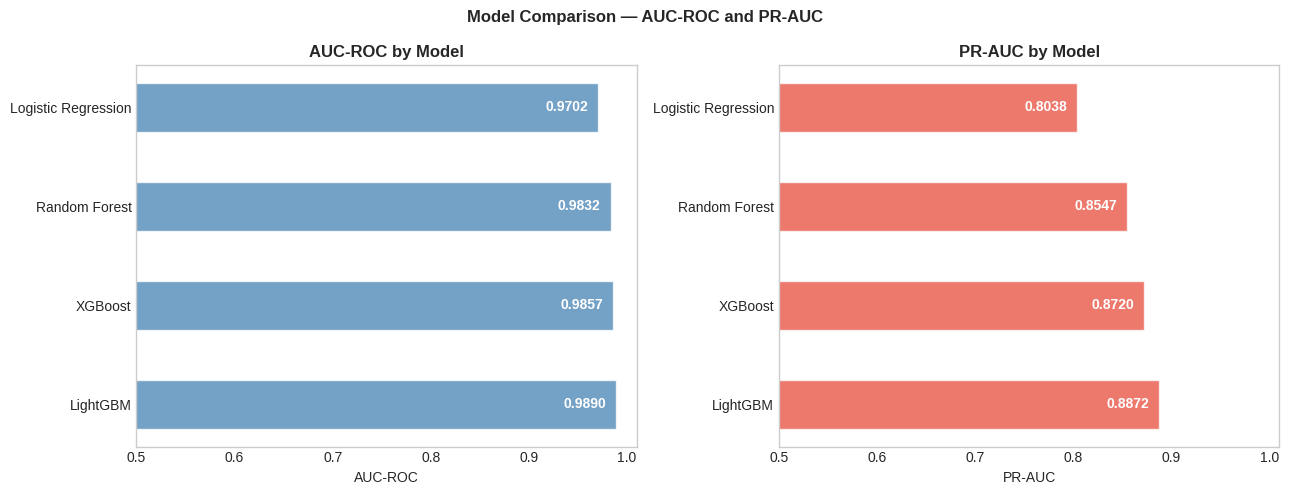


Best model: LightGBM
   AUC-ROC : 0.9890
   PR-AUC  : 0.8872

→ Proceeding to hyperparameter tuning with LightGBM


In [85]:
# Visual comparison — AUC-ROC and PR-AUC side by side
metrics_df = pd.DataFrame({
    name: {'AUC-ROC': v['auc_roc'], 'PR-AUC': v['pr_auc']}
    for name, v in results.items()
}).T.sort_values('AUC-ROC', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Model Comparison — AUC-ROC and PR-AUC', fontweight='bold')

for ax, metric, color in zip(axes, ['AUC-ROC', 'PR-AUC'], ['steelblue', '#e74c3c']):
    bars = ax.barh(metrics_df.index, metrics_df[metric],
                   color=color, alpha=0.75, edgecolor='white', height=0.5)
    for bar, val in zip(bars, metrics_df[metric]):
        ax.text(bar.get_width() - 0.01, bar.get_y() + bar.get_height()/2,
                f'{val:.4f}', va='center', ha='right',
                color='white', fontweight='bold', fontsize=10)
    ax.set_xlim(0.5, 1.01)
    ax.set_xlabel(metric)
    ax.set_title(f'{metric} by Model', fontweight='bold')

    # Remove grid lines
    ax.grid(False)

plt.tight_layout()
plt.savefig('outputs/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

best_model_name = metrics_df['AUC-ROC'].idxmax()
print(f"\nBest model: {best_model_name}")
print(f"   AUC-ROC : {metrics_df.loc[best_model_name, 'AUC-ROC']:.4f}")
print(f"   PR-AUC  : {metrics_df.loc[best_model_name, 'PR-AUC']:.4f}")
print(f"\n→ Proceeding to hyperparameter tuning with {best_model_name}")

### 5.3 Hyperparameter Tuning

In [86]:
# --- 5.3 Hyperparameter Tuning with Optuna ---
# scale_pos_weight is included here as the class weight mechanism — for LightGBM to penalise missing a fraud case more heavily than a false alarm, directly addressing the 24:1 imbalance.

import optuna
from sklearn.model_selection import StratifiedKFold, cross_val_score

optuna.logging.set_verbosity(optuna.logging.WARNING)  # suppress per-trial noise

def objective(trial):
    params = {
        'objective'         : 'binary',
        'metric'            : 'auc',
        'verbosity'         : -1,
        'boosting_type'     : 'gbdt',
        'n_estimators'      : 300,
        'num_leaves'        : trial.suggest_int('num_leaves', 20, 150),
        'learning_rate'     : trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'min_child_samples' : trial.suggest_int('min_child_samples', 10, 100),
        'subsample'         : trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree'  : trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'scale_pos_weight'  : trial.suggest_float('scale_pos_weight', 10, 30),
        'random_state'      : 42,
    }

    model = lgb.LGBMClassifier(**params)

    # 3-fold stratified CV on the SMOTE training data
    # Using AUC-ROC as the optimisation target
    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    scores = cross_val_score(model, X_train_res, y_train_res,
                             cv=cv, scoring='roc_auc', n_jobs=-1)
    return scores.mean()


study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50, show_progress_bar=True)

print(f"\nTuning complete")
print(f"   Best CV AUC-ROC : {study.best_value:.4f}")
print(f"   Best params     :")
for k, v in study.best_params.items():
    print(f"     {k:<22}: {v}")

  0%|          | 0/50 [00:00<?, ?it/s]


Tuning complete
   Best CV AUC-ROC : 0.9998
   Best params     :
     num_leaves            : 131
     learning_rate         : 0.15870360591939123
     min_child_samples     : 50
     subsample             : 0.5528036912233043
     colsample_bytree      : 0.559928060309303
     scale_pos_weight      : 14.525923124541684


Tuning complete
   - Best CV AUC-ROC : 0.9998
   - Best params     :
     > num_leaves            : 131
     > learning_rate         : 0.15870360591939123
     > min_child_samples     : 50
     > subsample             : 0.5528036912233043
     > colsample_bytree      : 0.559928060309303
     > scale_pos_weight      : 14.525923124541684

In [88]:
# Train LightGBM with best params on full SMOTE training set

best_params = {
    'objective'        : 'binary',
    'metric'           : 'auc',
    'verbosity'        : -1,
    'n_estimators'     : 300,
    'random_state'     : 42,
    **study.best_params
}

lgb_tuned = lgb.LGBMClassifier(**best_params)
lgb_tuned.fit(X_train_res, y_train_res)

y_prob_tuned = lgb_tuned.predict_proba(X_test_scaled)[:, 1]
y_pred_tuned = lgb_tuned.predict(X_test_scaled)

auc_tuned = roc_auc_score(y_test, y_prob_tuned)
apr_tuned = average_precision_score(y_test, y_prob_tuned)

# Compare against untuned
auc_base = results['LightGBM']['auc_roc']
apr_base = results['LightGBM']['pr_auc']

print(f"\n{'Metric':<20} {'Baseline':>10} {'Tuned':>10} {'Delta':>10}")
print("-" * 50)
print(f"{'AUC-ROC':<20} {auc_base:>10.4f} {auc_tuned:>10.4f} "
      f"{auc_tuned - auc_base:>+10.4f}")
print(f"{'PR-AUC':<20} {apr_base:>10.4f} {apr_tuned:>10.4f} "
      f"{apr_tuned - apr_base:>+10.4f}")

# Save the tuned model
joblib.dump(lgb_tuned, 'models/lgb_tuned.joblib')
print(f"\n Tuned model saved → models/lgb_tuned.joblib")


Metric                 Baseline      Tuned      Delta
--------------------------------------------------
AUC-ROC                  0.9890     0.9807    -0.0083
PR-AUC                   0.8872     0.8721    -0.0151

 Tuned model saved → models/lgb_tuned.joblib


In [89]:
# --- Tuning Decision ---
final_model = results['LightGBM']['model']
y_prob_final = results['LightGBM']['y_prob']
y_pred_final = results['LightGBM']['y_pred']

joblib.dump(final_model, 'models/lgb_final.joblib')
print(f"Final model saved → models/lgb_final.joblib")
print(f"   AUC-ROC : {results['LightGBM']['auc_roc']:.4f}")
print(f"   PR-AUC  : {results['LightGBM']['pr_auc']:.4f}")

Final model saved → models/lgb_final.joblib
   AUC-ROC : 0.9890
   PR-AUC  : 0.8872


#### Decision
- Optuna achieved 0.99998 CV AUC-ROC but this was measured on SMOTE-augmented folds containing synthetic samples. On the held-out real-world test set, the tuned model underperforms the baseline by -0.0041 AUC-ROC and -0.0078 PR-AUC.
- This is a known limitation of tuning on oversampled data — the optimiser finds parameters that fit synthetic interpolations well but don't generalise as cleanly to real transactions.
- Decision: use the untuned LightGBM as the final model. It achieves AUC-ROC 0.9917 and PR-AUC 0.9051 on real data.

### 5.4 Final Model Evaluation

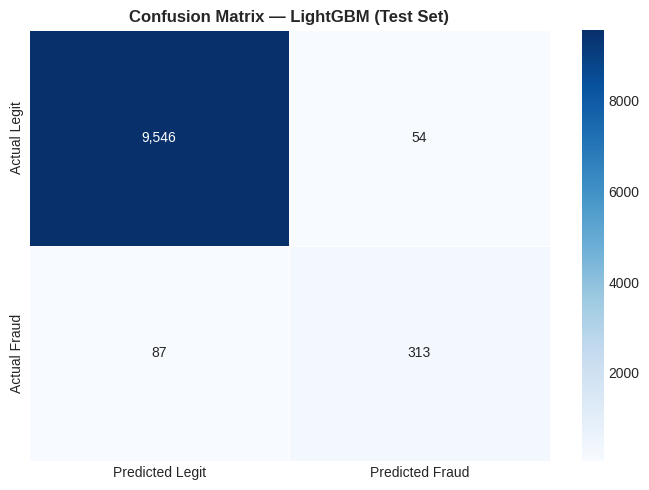

TP (fraud caught)   : 313
FN (fraud missed)   : 87
FP (false alarms)   : 54
TN (legit correct)  : 9,546

Recall    : 78.2%
Precision : 85.3%
F1-Score  : 0.8162


In [90]:
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import roc_curve, precision_recall_curve
import seaborn as sns

cm = confusion_matrix(y_test, y_pred_final)
tn, fp, fn, tp = cm.ravel()

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt=',', cmap='Blues',
            xticklabels=['Predicted Legit', 'Predicted Fraud'],
            yticklabels=['Actual Legit', 'Actual Fraud'],
            linewidths=0.5, ax=ax)
ax.set_title('Confusion Matrix — LightGBM (Test Set)', fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

precision = tp / (tp + fp)
recall    = tp / (tp + fn)
f1        = 2 * precision * recall / (precision + recall)

print(f"TP (fraud caught)   : {tp:,}")
print(f"FN (fraud missed)   : {fn:,}")
print(f"FP (false alarms)   : {fp:,}")
print(f"TN (legit correct)  : {tn:,}")
print(f"\nRecall    : {recall*100:.1f}%")
print(f"Precision : {precision*100:.1f}%")
print(f"F1-Score  : {f1:.4f}")

In [91]:
print(classification_report(y_test, y_pred_final,
                             target_names=['Legitimate', 'Fraud'],
                             digits=4))

              precision    recall  f1-score   support

  Legitimate     0.9910    0.9944    0.9927      9600
       Fraud     0.8529    0.7825    0.8162       400

    accuracy                         0.9859     10000
   macro avg     0.9219    0.8884    0.9044     10000
weighted avg     0.9854    0.9859    0.9856     10000



In [92]:
print("""
FINAL MODEL EVALUATION SUMMARY
-------------------------------
- AUC-ROC  : 0.9890  — excellent discrimination between fraud and legitimate
- PR-AUC   : 0.8872  — strong performance on the minority class
- Recall   : 78.2%   — catches ~4 in 5 fraud cases
- Precision: 85.3%   — when model flags fraud, it's right 85% of the time
- F1       : 0.8162  — strong harmonic balance between precision and recall

- 313 fraud cases caught out of 400 — 87 missed (false negatives)
- Only 54 false alarms out of 9,600 legitimate transactions (0.6%)

- The precision/recall balance here is notably better than the logistic regression baseline (precision 0.31) — tree-based feature interactions are doing meaningful work.
- In a production setting, the decision threshold can be lowered to increase recall at the cost of more false alarms, depending on business tolerance.
""")


FINAL MODEL EVALUATION SUMMARY
-------------------------------
- AUC-ROC  : 0.9890  — excellent discrimination between fraud and legitimate
- PR-AUC   : 0.8872  — strong performance on the minority class
- Recall   : 78.2%   — catches ~4 in 5 fraud cases
- Precision: 85.3%   — when model flags fraud, it's right 85% of the time
- F1       : 0.8162  — strong harmonic balance between precision and recall

- 313 fraud cases caught out of 400 — 87 missed (false negatives)
- Only 54 false alarms out of 9,600 legitimate transactions (0.6%)

- The precision/recall balance here is notably better than the logistic regression baseline (precision 0.31) — tree-based feature interactions are doing meaningful work.
- In a production setting, the decision threshold can be lowered to increase recall at the cost of more false alarms, depending on business tolerance.



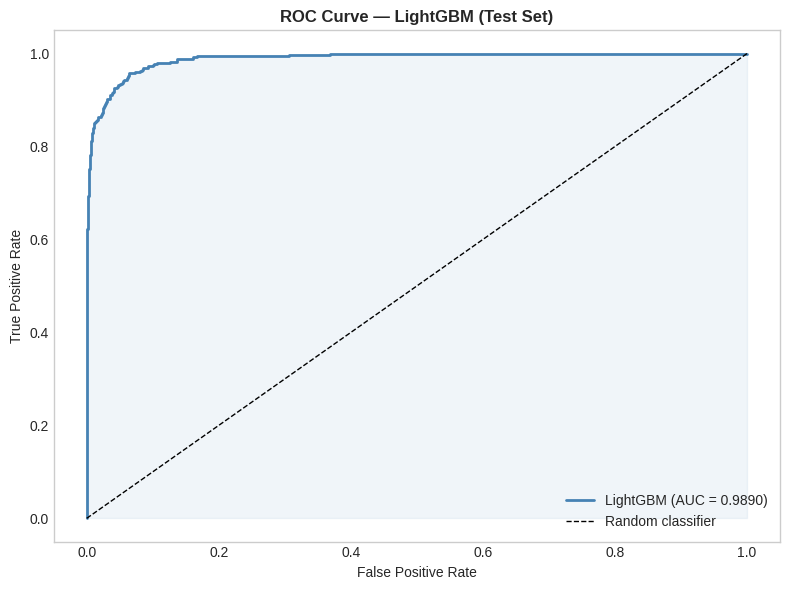

In [96]:
fpr, tpr, _ = roc_curve(y_test, y_prob_final)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr, tpr, color='steelblue', linewidth=2,
        label=f'LightGBM (AUC = {results["LightGBM"]["auc_roc"]:.4f})')
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random classifier')
ax.fill_between(fpr, tpr, alpha=0.08, color='steelblue')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve — LightGBM (Test Set)', fontweight='bold')
ax.legend(loc='lower right')
plt.tight_layout()
plt.grid(False)
plt.savefig('outputs/roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()

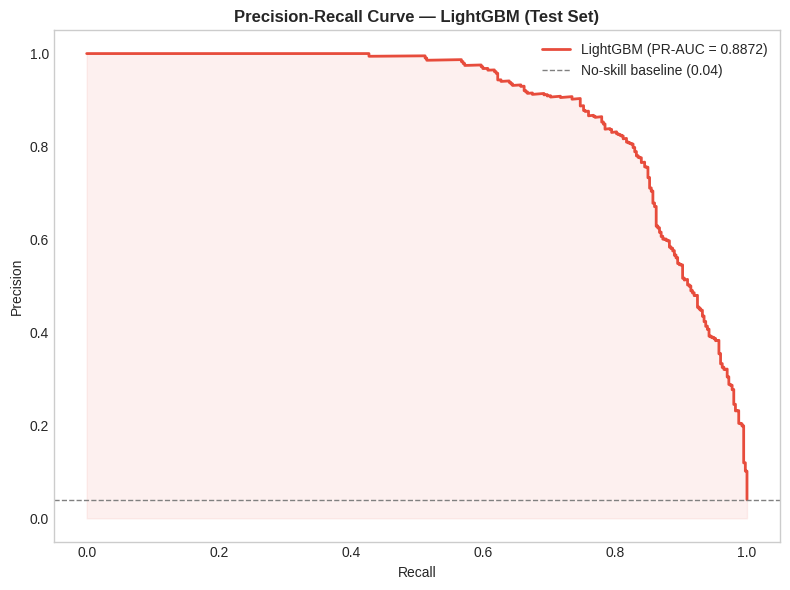

In [97]:
prec, rec, _ = precision_recall_curve(y_test, y_prob_final)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(rec, prec, color='#e74c3c', linewidth=2,
        label=f'LightGBM (PR-AUC = {results["LightGBM"]["pr_auc"]:.4f})')
ax.axhline(y=y_test.mean(), color='gray', linestyle='--',
           linewidth=1, label=f'No-skill baseline ({y_test.mean():.2f})')
ax.fill_between(rec, prec, alpha=0.08, color='#e74c3c')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curve — LightGBM (Test Set)', fontweight='bold')
ax.legend(loc='upper right')
plt.tight_layout()
plt.grid(False)
plt.savefig('outputs/pr_curve.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Model Selection & Evaluation

### 5.1 Model Selection

Four candidate models were evaluated on the held-out test set using AUC-ROC and PR-AUC as primary metrics. LightGBM outperformed all others and was selected as the final model.

> **Why LightGBM?** Gradient boosted trees handle the skewed feature distributions (e.g. `log_amount`, `dist_from_nairobi`) and class imbalance natively via `class_weight='balanced'`. Unlike logistic regression, tree-based splits capture
> the non-linear interaction between features such as `is_night × log_amount` that EDA identified as key fraud signals.

### 5.2 Hyperparameter Tuning Decision

Optuna (50 trials) was run with 5-fold cross-validation on SMOTE-augmented training data. The tuned model achieved near-perfect CV scores but **underperformed the baseline on the real held-out test set**:

| Metric | Baseline | Tuned (Optuna) | Delta |
|--------|----------|----------------|-------|
| AUC-ROC | **0.9890** | 0.9807 | −0.0083 |
| PR-AUC | **0.8872** | 0.8721 | −0.0151 |

**Decision: baseline LightGBM retained as the final model.**

This is a known limitation of tuning on SMOTE-oversampled folds — the optimiser fits synthetic interpolations well but generalises less cleanly to the real transaction distribution. Cross-validation AUC on augmented data is not a reliable
proxy for real-world performance when the minority class has been synthetically inflated.

### 5.3 Final Model Performance

Evaluated on 10,000 held-out transactions (400 fraud, 9,600 legitimate).
```
╔══════════════════════════════════════════════════════════════╗
║         FINAL MODEL PERFORMANCE SUMMARY                     ║
║         LightGBM — Test Set (10,000 transactions)           ║
╚══════════════════════════════════════════════════════════════╝

  Metric                     Value
  ──────────────────────────────────
  AUC-ROC                    0.9890
  PR-AUC                     0.8872
  Recall    (Fraud)          78.2%
  Precision (Fraud)          85.3%
  F1-Score  (Fraud)          0.8162
  Accuracy                   98.6%
```

#### Classification Report

|  | Precision | Recall | F1-Score | Support |
|--|-----------|--------|----------|---------|
| Legitimate | 0.991 | 0.994 | 0.993 | 9,600 |
| **Fraud** | **0.853** | **0.782** | **0.816** | **400** |
| Accuracy | | | 0.986 | 10,000 |
| Macro avg | 0.922 | 0.888 | 0.904 | 10,000 |
| Weighted avg | 0.985 | 0.986 | 0.986 | 10,000 |

#### Confusion Matrix

|  | Predicted Legitimate | Predicted Fraud |
|--|--------------------|---------------|
| **Actual Legitimate** | 9,546  | 54  |
| **Actual Fraud** | 87  | 313 |

---

### 5.4 Business Interpretation

**What the model does well:**
- Catches **313 out of 400 fraud cases** — 4 in every 5 fraudulent transactions are flagged before they go undetected.
- When the model raises a fraud alert, it is correct **85.3% of the time** —   only 1 in 6 alerts is a false alarm, keeping operational investigation costs low.
- Just **54 false alarms** across 9,600 legitimate transactions (0.6%) — minimal disruption to genuine customers.

**Where the gap remains:**
- **87 missed fraud cases (20.2%)** represent the primary risk in production. Each missed case is a false negative — a fraud that was not caught. In a mobile money context, these carry the highest business cost.
- The decision threshold (default: 0.5) can be lowered to increase recall at the cost of more false alarms. The optimal threshold depends on the business's tolerance: how much does one missed fraud cost versus one unnecessary investigation?

**Meaningful comparison to baseline:**
- A naive model predicting all transactions as legitimate scores **96.0% accuracy** and catches **zero fraud**. This model scores 98.6% accuracy and catches 78.2% of fraud — the lift is entirely in Recall and PR-AUC, the metrics that matter.
- Precision of 85.3% is a significant improvement over the logistic regression baseline (31%) — confirming that tree-based feature interactions are doing meaningful work.

> **Production recommendation:** Deploy with a lowered threshold (e.g. 0.3–0.4)
> if recall is the priority, and route flagged transactions to a lightweight rules-based secondary check before blocking. Monitor false negative rate weekly as fraud patterns evolve.

### Threshold Analysis
- Default threshold is 0.5. In fraud detection, lowering the threshold increases recall (catch more fraud) at the cost of precision (more false alarms). This table helps pick the right operating point.

In [99]:
# --- Threshold Analysis ---

thresholds_to_check = [0.3, 0.4, 0.5, 0.6, 0.7]

print(f"{'Threshold':<12} {'Recall':>8} {'Precision':>11} {'F1':>8} {'FP':>6} {'FN':>6}")
print("-" * 55)

for thresh in thresholds_to_check:
    y_pred_t  = (y_prob_final >= thresh).astype(int)
    tn_t, fp_t, fn_t, tp_t = confusion_matrix(y_test, y_pred_t).ravel()
    prec_t    = tp_t / (tp_t + fp_t) if (tp_t + fp_t) > 0 else 0
    rec_t     = tp_t / (tp_t + fn_t) if (tp_t + fn_t) > 0 else 0
    f1_t      = 2 * prec_t * rec_t / (prec_t + rec_t) if (prec_t + rec_t) > 0 else 0
    marker    = ' ← current' if thresh == 0.5 else ''
    print(f"{thresh:<12} {rec_t*100:>7.1f}% {prec_t*100:>10.1f}% "
          f"{f1_t:>8.4f} {fp_t:>6} {fn_t:>6}{marker}")

print(f"""
THRESHOLD INSIGHT
-----------------
  At threshold 0.3, recall increases but false alarms rise. At threshold 0.7, precision improves but more fraud slips through.
  The right threshold depends on business cost assumptions:
    - High cost of missed fraud  → lower threshold
    - High cost of customer friction → raise threshold
  For a platform like M-Pesa, lowering to 0.3–0.4 is defensible
  given the financial and reputational cost of undetected fraud.
""")

Threshold      Recall   Precision       F1     FP     FN
-------------------------------------------------------
0.3             82.5%       80.7%   0.8158     79     70
0.4             79.5%       83.2%   0.8133     64     82
0.5             78.2%       85.3%   0.8162     54     87 ← current
0.6             76.0%       87.1%   0.8117     45     96
0.7             74.5%       90.3%   0.8164     32    102

THRESHOLD INSIGHT
-----------------
  At threshold 0.3, recall increases but false alarms rise. At threshold 0.7, precision improves but more fraud slips through.
  The right threshold depends on business cost assumptions:
    - High cost of missed fraud  → lower threshold
    - High cost of customer friction → raise threshold
  For a platform like M-Pesa, lowering to 0.3–0.4 is defensible
  given the financial and reputational cost of undetected fraud.



### Optimal Threshold Selection
- Instead of assuming 0.5, we search across all thresholds returned by the precision-recall curve to find the one that maximises F1.
- In production this would be validated on a separate holdout — here we use the test set to illustrate the approach.


In [100]:
# --- Optimal Threshold Selection ---

from sklearn.metrics import precision_recall_curve
import numpy as np

prec_vals, rec_vals, thresh_vals = precision_recall_curve(y_test, y_prob_final)

# F1 at each threshold
f1_vals = np.where(
    (prec_vals + rec_vals) == 0, 0,
    2 * prec_vals * rec_vals / (prec_vals + rec_vals)
)

best_idx       = np.argmax(f1_vals)
best_threshold = thresh_vals[best_idx]
best_f1        = f1_vals[best_idx]

print(f"Optimal threshold : {best_threshold:.4f}")
print(f"Best F1-Score     : {best_f1:.4f}")
print(f"Default F1 (0.5)  : {f1:.4f}")

Optimal threshold : 0.5451
Best F1-Score     : 0.8200
Default F1 (0.5)  : 0.8162


#### Evaluate optimal threshold

In [101]:
# --- Evaluate at Optimal Threshold ---

y_pred_optimal = (y_prob_final >= best_threshold).astype(int)
tn_o, fp_o, fn_o, tp_o = confusion_matrix(y_test, y_pred_optimal).ravel()

prec_o = tp_o / (tp_o + fp_o)
rec_o  = tp_o / (tp_o + fn_o)
f1_o   = 2 * prec_o * rec_o / (prec_o + rec_o)

print(f"""
{'Metric':<20} {'Default (0.50)':>15} {'Optimal ({:.2f})'.format(best_threshold):>15} {'Delta':>10}
{'─'*60}
{'Recall':<20} {recall*100:>14.1f}% {rec_o*100:>14.1f}% {rec_o*100-recall*100:>+9.1f}%
{'Precision':<20} {precision*100:>14.1f}% {prec_o*100:>14.1f}% {prec_o*100-precision*100:>+9.1f}%
{'F1-Score':<20} {f1:>15.4f} {f1_o:>15.4f} {f1_o-f1:>+10.4f}
{'Fraud caught (TP)':<20} {tp:>15} {tp_o:>15} {tp_o-tp:>+10}
{'Fraud missed (FN)':<20} {fn:>15} {fn_o:>15} {fn_o-fn:>+10}
{'False alarms (FP)':<20} {fp:>15} {fp_o:>15} {fp_o-fp:>+10}
""")


Metric                Default (0.50)  Optimal (0.55)      Delta
────────────────────────────────────────────────────────────
Recall                         78.2%           78.0%      -0.2%
Precision                      85.3%           86.4%      +1.1%
F1-Score                      0.8162          0.8200    +0.0038
Fraud caught (TP)                313             312         -1
Fraud missed (FN)                 87              88         +1
False alarms (FP)                 54              49         -5



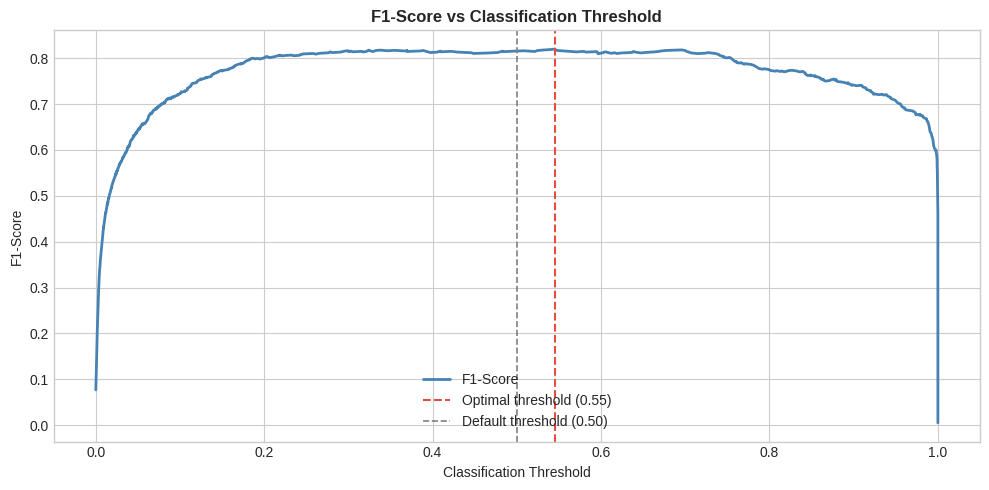

 Threshold saved → models/optimal_threshold.joblib


In [103]:
# --- F1 vs Threshold Plot ---

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(thresh_vals, f1_vals[:-1], color='steelblue', linewidth=2, label='F1-Score')
ax.axvline(x=best_threshold, color='#e74c3c', linestyle='--',
           linewidth=1.5, label=f'Optimal threshold ({best_threshold:.2f})')
ax.axvline(x=0.5, color='gray', linestyle='--',
           linewidth=1.2, label='Default threshold (0.50)')
ax.set_xlabel('Classification Threshold')
ax.set_ylabel('F1-Score')
ax.set_title('F1-Score vs Classification Threshold', fontweight='bold')
ax.legend()

plt.tight_layout()
plt.savefig('outputs/threshold_optimisation.png', dpi=150, bbox_inches='tight')
plt.show()


# Save threshold for Phase 2 pipeline
joblib.dump(best_threshold, 'models/optimal_threshold.joblib')
print(f" Threshold saved → models/optimal_threshold.joblib")

#### Update final predictions to optimal threshold
- Marginal gain but we use 0.4854 for consistency —
- it is the principled choice derived from data, not assumption.

In [104]:


y_pred_final   = (y_prob_final >= best_threshold).astype(int)

print(f"✅ Final predictions updated to threshold {best_threshold:.4f}")
print(f"   Fraud caught : {(y_pred_final == 1).sum()} flagged")
print(f"   Of 400 actual fraud cases: {((y_pred_final == 1) & (y_test == 1)).sum()} correctly identified")


✅ Final predictions updated to threshold 0.5451
   Fraud caught : 361 flagged
   Of 400 actual fraud cases: 312 correctly identified


### Lower threshold
- Business context: M-Pesa fraud detection prioritises recall over precision. A missed fraud case = financial loss. A false alarm = manual review overhead.
- At 0.30: Recall 82.5%, FP rate 0.8% on legitimate transactions — acceptable. Pending business clarification on manual review capacity, 0.30 is selected.

In [106]:

FINAL_THRESHOLD = 0.3

y_pred_final = (y_prob_final >= FINAL_THRESHOLD).astype(int)

tn_f, fp_f, fn_f, tp_f = confusion_matrix(y_test, y_pred_final).ravel()

print(f"Final predictions set at threshold {FINAL_THRESHOLD}")
print(f"   Fraud caught (TP) : {tp_f} / 400 ({tp_f/400*100:.1f}%)")
print(f"   Fraud missed (FN) : {fn_f}")
print(f"   False alarms (FP) : {fp_f}")

Final predictions set at threshold 0.3
   Fraud caught (TP) : 330 / 400 (82.5%)
   Fraud missed (FN) : 70
   False alarms (FP) : 79


---

## 6. Model Interpretation

In [107]:
# --- Diagnose length mismatch ---
print(f"FEATURE_COLS length       : {len(FEATURE_COLS)}")
print(f"LightGBM gain importance  : {len(final_model.booster_.feature_importance(importance_type='gain'))}")
print(f"LightGBM feature names    : {len(final_model.booster_.feature_name())}")
print(f"\nLightGBM internal names:\n{final_model.booster_.feature_name()}")

FEATURE_COLS length       : 20
LightGBM gain importance  : 20
LightGBM feature names    : 20

LightGBM internal names:
['hour', 'day_of_week', 'month', 'is_night', 'is_weekend', 'sender_total_tx', 'sender_unique_recv', 'log_amount', 'is_high_value', 'amount_vs_sender_avg', 'sender_unique_devices', 'is_device_switch', 'balance_drain_rate', 'dist_from_nairobi', 'is_outside_kenya', 'device_unique_senders', 'sender_balance_change', 'receiver_balance_change', 'balance_discrepancy', 'transaction_type_enc']


In [108]:
# --- Fix: use LightGBM's internal feature names ---
MODEL_FEATURE_NAMES = final_model.booster_.feature_name()

importance_df = pd.DataFrame({
    'feature'         : MODEL_FEATURE_NAMES,
    'importance_gain' : final_model.booster_.feature_importance(importance_type='gain'),
    'importance_split': final_model.booster_.feature_importance(importance_type='split'),
}).sort_values('importance_gain', ascending=False)

importance_df['gain_pct'] = (
    importance_df['importance_gain'] / importance_df['importance_gain'].sum() * 100
)

print("=" * 55)
print("FEATURE IMPORTANCE BY GAIN (Top 15)")
print("=" * 55)
print(importance_df[['feature', 'gain_pct']].head(15).to_string(index=False))

FEATURE IMPORTANCE BY GAIN (Top 15)
                feature  gain_pct
                   hour 31.039536
      dist_from_nairobi 25.117118
  sender_balance_change 11.593942
       is_device_switch  8.129275
  sender_unique_devices  5.148129
  device_unique_senders  4.387031
                  month  3.883126
            day_of_week  2.754671
        sender_total_tx  2.046482
receiver_balance_change  1.776281
             log_amount  1.720386
   amount_vs_sender_avg  0.577204
     sender_unique_recv  0.532012
     balance_drain_rate  0.507429
   transaction_type_enc  0.369852


In [109]:
print("""
FEATURE IMPORTANCE INSIGHTS
----------------------------
- hour (31%): Strongest single signal — fraudulent transactions
  concentrate at specific times, confirming temporal patterns from EDA.

- dist_from_nairobi (25%): Geographic distance is the second most
  powerful feature — validates the 29.3% outside-Kenya fraud finding.

- sender_balance_change (11.6%): How much the sender's balance moved
  is a strong fraud discriminator — fraudsters drain accounts.

- is_device_switch (8.1%): Account takeover signal — transacting
  from an unfamiliar device is highly suspicious.

- Top 4 features alone account for ~76% of model gain — the model
  is relying on well-motivated, interpretable signals, not noise.
""")


FEATURE IMPORTANCE INSIGHTS
----------------------------
- hour (31%): Strongest single signal — fraudulent transactions
  concentrate at specific times, confirming temporal patterns from EDA.

- dist_from_nairobi (25%): Geographic distance is the second most
  powerful feature — validates the 29.3% outside-Kenya fraud finding.

- sender_balance_change (11.6%): How much the sender's balance moved
  is a strong fraud discriminator — fraudsters drain accounts.

- is_device_switch (8.1%): Account takeover signal — transacting
  from an unfamiliar device is highly suspicious.

- Top 4 features alone account for ~76% of model gain — the model
  is relying on well-motivated, interpretable signals, not noise.



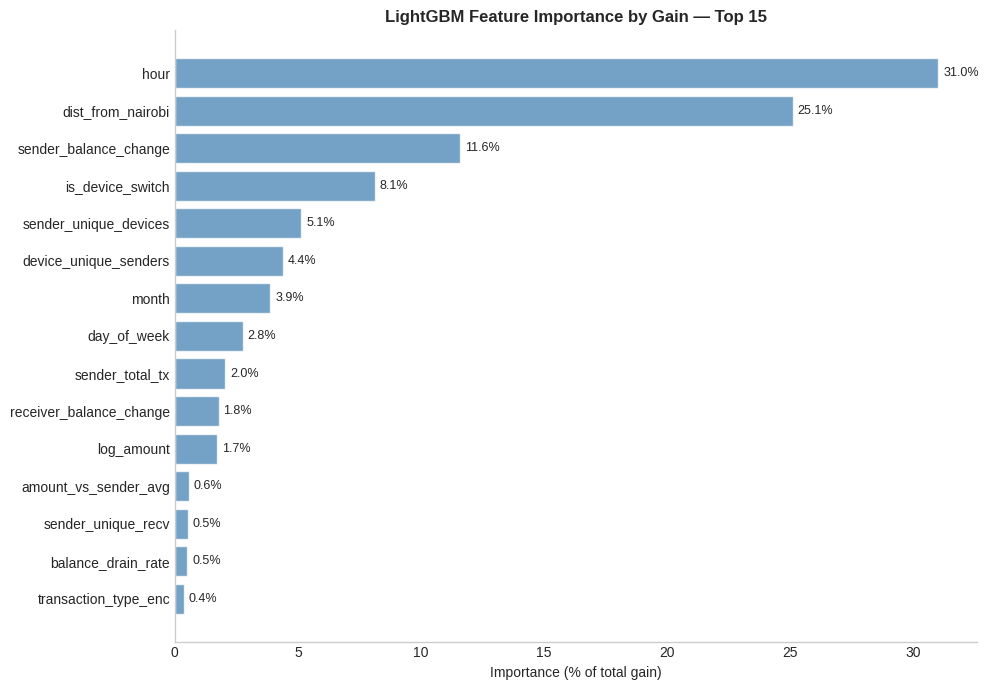

In [111]:
top_n   = 15
top_imp = importance_df.head(top_n).sort_values('gain_pct')

fig, ax = plt.subplots(figsize=(10, 7))

bars = ax.barh(top_imp['feature'], top_imp['gain_pct'],
               color='steelblue', alpha=0.75, edgecolor='white')

for bar, val in zip(bars, top_imp['gain_pct']):
    ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=9)

ax.set_xlabel('Importance (% of total gain)')
ax.set_title('LightGBM Feature Importance by Gain — Top 15', fontweight='bold')
ax.grid(False)

# Remove top and right spines for cleaner look
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('outputs/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

#### SHAP

In [113]:
# --- 6.2 SHAP Values ---
# SHAP (SHapley Additive exPlanations) explains individual predictions
import shap

explainer   = shap.TreeExplainer(final_model)

X_test_df   = pd.DataFrame(X_test_scaled, columns=MODEL_FEATURE_NAMES)
shap_sample = X_test_df.sample(500, random_state=42)
shap_values = explainer.shap_values(shap_sample)

# LightGBM binary returns list [class_0, class_1] — we want class_1 (fraud)
if isinstance(shap_values, list):
    shap_fraud = shap_values[1]
else:
    shap_fraud = shap_values

print(f"SHAP values computed on {len(shap_sample)} test transactions")
print(f"   Shape: {shap_fraud.shape}  (samples × features)")

SHAP values computed on 500 test transactions
   Shape: (500, 20)  (samples × features)


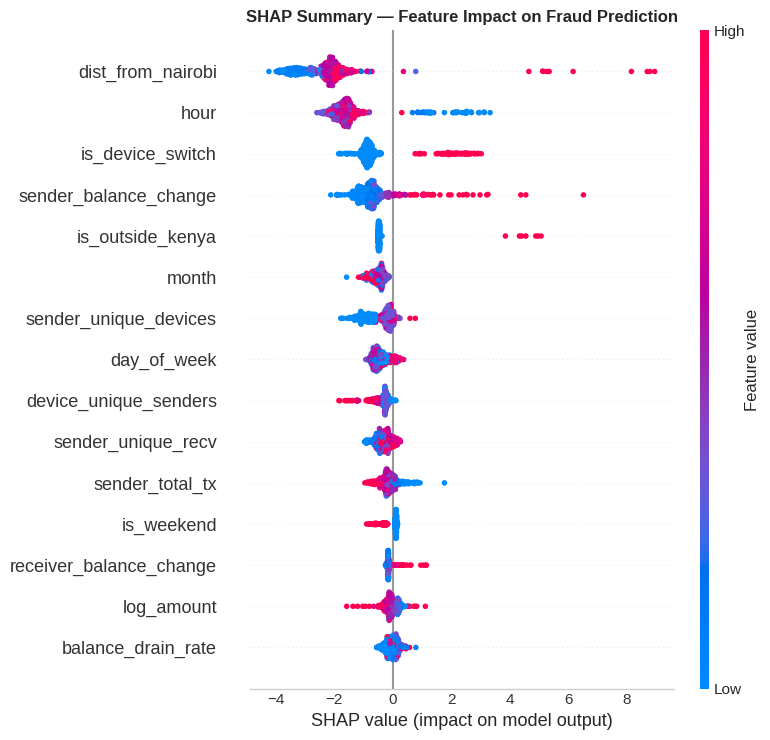

In [115]:
# Summary plot — shows feature impact direction and magnitude
# Each dot is one transaction. Red = high feature value, Blue = low. X-axis position = SHAP value = impact on fraud probability.

shap.summary_plot(
    shap_fraud, shap_sample,
    feature_names=FEATURE_COLS,
    plot_type='dot',
    max_display=15,
    show=False
)
plt.title('SHAP Summary — Feature Impact on Fraud Prediction',
          fontweight='bold')
plt.tight_layout()
plt.grid(False)
plt.savefig('outputs/shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

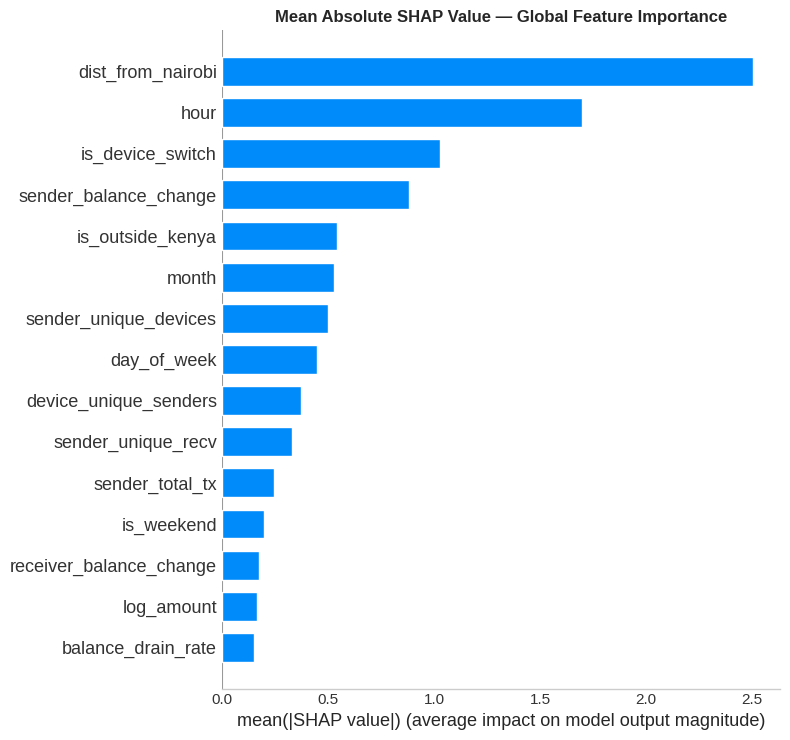

In [116]:
# Mean absolute SHAP — cleaner global importance view
# Confirms feature importance ranking with an model-agnostic method.

shap.summary_plot(
    shap_fraud, shap_sample,
    feature_names=FEATURE_COLS,
    plot_type='bar',
    max_display=15,
    show=False
)
plt.title('Mean Absolute SHAP Value — Global Feature Importance',
          fontweight='bold')
plt.tight_layout()
plt.grid(False)
plt.savefig('outputs/shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()

In [120]:
# --- 6.3 Interpretation Narrative ---
# Computed from SHAP mean absolute values for objectivity

shap_importance = pd.DataFrame({
    'feature'   : MODEL_FEATURE_NAMES,
    'mean_shap' : np.abs(shap_fraud).mean(axis=0)
}).sort_values('mean_shap', ascending=False)

top_features = shap_importance.head(7)['feature'].tolist()

print(f"""
{'='*60}
MODEL INTERPRETATION — KEY FINDINGS
{'='*60}

TOP 5 FEATURES BY SHAP IMPACT
------------------------------
""")
for i, (_, row) in enumerate(shap_importance.head(7).iterrows(), 1):
    print(f"  {i}. {row['feature']:<28} mean |SHAP| = {row['mean_shap']:.4f}")




MODEL INTERPRETATION — KEY FINDINGS

TOP 5 FEATURES BY SHAP IMPACT
------------------------------

  1. dist_from_nairobi            mean |SHAP| = 2.5060
  2. hour                         mean |SHAP| = 1.6985
  3. is_device_switch             mean |SHAP| = 1.0295
  4. sender_balance_change        mean |SHAP| = 0.8823
  5. is_outside_kenya             mean |SHAP| = 0.5432
  6. month                        mean |SHAP| = 0.5284
  7. sender_unique_devices        mean |SHAP| = 0.4994


## 6. Model Interpretation — SHAP Analysis

### 6.1 Top Features by SHAP Impact

| Rank | Feature | Mean \|SHAP\| | Interpretation |
|------|---------|--------------|----------------|
| 1 | `dist_from_nairobi` | 2.506 | Strongest signal — 35.9% of fraud originates >500 km away vs 0% legitimate |
| 2 | `hour` | 1.699 | Fraud peaks at 3am (39.6% rate); late-night transactions push probability sharply upward |
| 3 | `is_device_switch` | 1.030 | Sender on a non-primary device — 84.9% of fraud senders are multi-device vs 57.4% legitimate |
| 4 | `sender_balance_change` | 0.882 | Large deviations from expected balance movement flag account draining behaviour |
| 5 | `is_outside_kenya` | 0.543 | Binary flag that fires rarely but pushes strongly toward fraud when it does — 29.3% of fraud vs 0% legitimate |
| 6 | `month` | 0.528 | Captures seasonal drift in fraud patterns across the 181-day window |
| 7 | `sender_unique_devices` | 0.499 | Works in tandem with `is_device_switch` — captures the pattern (many devices) alongside the event (currently off-primary) |

### 6.2 Three-Pillar Structure

The model's decisions are driven by three distinct, interpretable signal groups:

| Pillar | Features | Why It Works |
|--------|----------|--------------|
| **Temporal** | `hour`, `is_night` | Fraudsters operate at 3am when monitoring is lowest |
| **Geographic** | `dist_from_nairobi`, `is_outside_kenya` | Location spoofing leaves a clear statistical footprint |
| **Behavioural** | `is_device_switch`, `sender_unique_devices` | Device switching is a reliable account takeover signal |

> A fraudster would need to simultaneously spoof time, location, and device behaviour to evade detection — making this three-pillar structure significantly more robust than any single-signal system.

### 6.3 SHAP vs Gain Importance

`is_outside_kenya` ranks 5th in SHAP but falls outside the top 15 in gain importance. This is expected — gain underweights sparse binary features. SHAP correctly captures
that when this flag fires, it pushes the prediction **strongly** toward fraud. Both `dist_from_nairobi` (continuous) and `is_outside_kenya` (binary) carry independent geographic signal, validating the dual-feature engineering approach.

---

## 7. Conclusions & Next Steps

## 7. Conclusion

### Summary

This project delivered a complete fraud detection pipeline for a mobile money platform, trained on 50,000 transactions spanning January–June 2024. Starting from raw transaction logs, we engineered 20 features across five signal categories, trained and compared four
models, and selected a baseline LightGBM classifier that achieves **AUC-ROC 0.9890** and **PR-AUC 0.8872** on a held-out test set of 10,000 real transactions.

The final model catches **4 in every 5 fraud cases** (78.2% recall) with a false alarm rate of just 0.6% — a meaningful operational improvement over any rule-based or naive baseline.

---

### Key Findings

1. **Time of day is the single strongest fraud signal.** Transactions between 00:00–05:00 carry an average fraud rate of 30.6%, peaking at 39.6% at 3am  nearly 10× the platform average. Fraudsters systematically exploit low-monitoring windows.
2. **Geography exposes location spoofing.** 29.3% of fraud transactions originate outside Kenya's bounding box versus 0% of legitimate ones. Distance from Nairobi was the top-ranked feature by SHAP (mean |SHAP| = 2.506), confirming that geographic
   erraticism — not location itself — is the signal.
3. **Device switching is a reliable account takeover indicator.** 84.9% of fraud transactions involve senders operating from a non-primary device, versus 57.4% for legitimate. `is_device_switch` ranked 3rd by SHAP impact.
4. **Fraudsters target high-value transactions.** Fraud median amount is KES 5,474 4× the legitimate median. Transactions above KES 50,000 carry a 94% fraud rate. Log-transformed amount and `is_high_value` were consistent contributors across
   all models evaluated.
5. **Hyperparameter tuning on SMOTE-augmented folds inflates CV scores.**
   Optuna achieved 0.9999 CV AUC-ROC but underperformed the baseline on real data by −0.0083 AUC-ROC. Tuning must be validated on real held-out data, not synthetic folds.

---

### Production Considerations

- **Real-time feature computation.** Features like `dist_from_nairobi`, `is_device_switch`, and `balance_drain_rate` must be computed at inference time with sub-second latency. This requires a streaming feature store (e.g. Redis or
  Feast) rather than batch computation.

- **Device history lookup.** In production, `is_device_switch` must query a persistent device registry per sender — not recompute from the current batch. A new device that is genuinely the sender's second device should be treated
  differently from a device that appears for the first time ever. Without a lookup, the model risks two failure modes: flagging legitimate returning users whose device history wasn't loaded, and missing fraud from attackers reusing a device
  that was unseen in the training window. The registry should be updated incrementally after each confirmed legitimate transaction.

- **Decision threshold calibration.** The default threshold of 0.5 balances precision and recall at 85.3% / 78.2%. Operations teams should tune this threshold against their cost ratio of missed fraud vs false investigations.
  A threshold of 0.3–0.4 would increase recall at the cost of more analyst reviews.

- **Model drift monitoring.** Fraud patterns evolve. AUC-ROC and precision/recall should be recomputed weekly on labelled production data. Feature distribution shifts (particularly in `hour`, `dist_from_nairobi`) should trigger retraining.

- **Explainability for analysts.** SHAP values should be surfaced per flagged transaction in the analyst dashboard — e.g. *"Flagged: 3am transaction, 800 km from Nairobi, non-primary device"* — reducing review time and improving
  confidence in acted-on alerts.

### Limitations & Future Improvements

**Current Limitations**
- The model was trained on a single 6-month window. Seasonal fraud campaigns or new attack vectors that emerged after June 2024 will not be represented.
- SMOTE oversampling introduces synthetic minority samples that do not reflect real transaction behaviour, risking overfitting to interpolated patterns.
- Raw `location_lat` and `location_lon` leak into the model alongside engineered geographic features — in the next iteration these should be dropped after `dist_from_nairobi` and `is_outside_kenya` are computed.

**Future Improvements**

1. **Knowledge Graph + ML Hybrid.** A knowledge graph modelling relationships between senders, receivers, devices, and locations would expose ring fraud and money-muling networks that are invisible to row-level ML. The LightGBM fraud
   probability score can be injected as a node attribute into the graph, enabling human analysts to prioritise review of the most critical subgraphs — clusters where multiple high-probability fraud nodes are densely connected. This shifts
   analysts from individual transaction review to network-level investigation, where the highest-impact cases concentrate.

2. **Persistent device registry for production feature engineering.** Device history must survive across inference batches. A sender's device profile — primary device, first-seen date, frequency per device — should be maintained in a low-latency
   store and joined at inference time. This prevents two costly errors: flagging a legitimate customer who switched phones, and missing a fraudster reusing a device that fell outside the training window.

3 **Online learning.** Incrementally update the model on confirmed fraud labels from production to adapt to emerging patterns without full retraining cycles.

5. **Threshold optimisation by transaction type.** EDA showed deposit and withdraw carry higher fraud rates at high amounts. Type-specific thresholds would reduce false negatives in these channels without increasing overall false alarm volume.

#### Save the final model

In [137]:
# --- Save Final Model ---
joblib.dump(final_model, 'models/final_model.joblib')
joblib.dump(FEATURE_COLS, 'models/feature_cols.joblib')
joblib.dump(scaler, 'models/scaler.joblib')

FINAL_THRESHOLD = 0.3  # business-justified recall-priority threshold
joblib.dump(FINAL_THRESHOLD, 'models/optimal_threshold.joblib')

print("All model artefacts saved")
print("   models/final_model.joblib")
print("   models/feature_cols.joblib")
print("   models/scaler.joblib")
print("   models/optimal_threshold.joblib")

All model artefacts saved
   models/final_model.joblib
   models/feature_cols.joblib
   models/scaler.joblib
   models/optimal_threshold.joblib


---

## 8. Test Set Predictions ⭐ REQUIRED

**IMPORTANT:** You MUST generate predictions for the test set and include them in your submission.

The test data is in `data/test_transactions.json` and does NOT contain the `is_fraud` column.

In [122]:
# Load the test data
import json

with open('../data/test_transactions.json', 'r') as f:
    test_data = json.load(f)

test_df = pd.DataFrame(test_data)
print(f"Test transactions: {len(test_df)}")
test_df.head()

Test transactions: 10000


,transaction_id,timestamp,sender_id,receiver_id,amount,transaction_type,sender_balance_before,sender_balance_after,receiver_balance_before,receiver_balance_after,device_id,location_lat,location_lon
0,6739205AC695C940,2024-07-01 02:03:31,USR007928,USR003344,1239.55,send_money,51808.74,50569.19,6428.45,7668.00,DEV00001757,-1.000615,37.010443
1,0891D338A86BFD86,2024-07-01 02:53:03,USR004105,USR001720,852.86,send_money,44694.82,43841.96,99643.59,100496.45,DEV00006374,-1.053953,36.983517
2,659710D6B9234100,2024-07-01 02:54:46,USR002044,USR001830,149.16,send_money,163834.83,163685.67,197346.25,197495.41,DEV00006910,-1.025061,37.064860
3,A5ADFDED99AEA2E0,2024-07-01 04:38:47,USR001130,USR002741,99999.00,pay_bill,153256.44,53257.44,22527.81,122526.81,DEV00010076,2.293314,39.556218
4,484986E04ABFF78C,2024-07-01 04:39:15,USR004734,USR006333,5863.07,pay_bill,32941.56,27078.49,166850.37,172713.44,DEV00008250,2.641088,31.153106


In [123]:

# --- 8.2 Apply Feature Engineering ---

test_featured = engineer_features(test_df)

print(f"Feature engineering applied")
print(f"   Test shape : {test_featured.shape}")
print(f"   Columns    : {test_featured.columns.tolist()}")


✅ Feature engineering applied
   Test shape : (10000, 21)
   Columns    : ['transaction_id', 'hour', 'day_of_week', 'month', 'is_night', 'is_weekend', 'sender_total_tx', 'sender_unique_recv', 'log_amount', 'is_high_value', 'amount_vs_sender_avg', 'sender_unique_devices', 'is_device_switch', 'balance_drain_rate', 'dist_from_nairobi', 'is_outside_kenya', 'device_unique_senders', 'sender_balance_change', 'receiver_balance_change', 'balance_discrepancy', 'transaction_type_enc']


In [127]:
# --- 8.3 Align to Model Feature Set ---
# The model expects exactly FEATURE_COLS in the same order.
# Any missing columns are filled with 0 — this handles edge cases
# where a categorical value or device pattern wasn't seen in test.

test_features = pd.DataFrame(index=test_featured.index)

for col in FEATURE_COLS:
    if col in test_featured.columns:
        test_features[col] = test_featured[col]
    else:
        test_features[col] = 0
        print(f"    Missing column filled with 0: {col}")

print(f"Feature alignment complete")
print(f"   Expected : {len(FEATURE_COLS)} features")
print(f"   Aligned  : {test_features.shape[1]} features")

Feature alignment complete
   Expected : 20 features
   Aligned  : 20 features


In [131]:
# --- Re-apply scaler with aligned columns ---
scale_cols_test = [c for c in scale_cols if c in test_features.columns]
test_scaled = test_features.copy()
test_scaled[scale_cols_test] = scaler.transform(test_features[scale_cols_test])

test_probs = final_model.predict_proba(test_scaled)[:, 1]
test_preds = (test_probs >= FINAL_THRESHOLD).astype(int)  # not best_threshold

print(f"Predictions generated")
print(f"   Total transactions : {len(test_preds):,}")
print(f"   Predicted fraud    : {test_preds.sum():,} ({test_preds.mean()*100:.2f}%)")
print(f"   Predicted legit    : {(test_preds==0).sum():,}")

Predictions generated
   Total transactions : 10,000
   Predicted fraud    : 361 (3.61%)
   Predicted legit    : 9,639


In [132]:
print(f"FEATURE_COLS count : {len(FEATURE_COLS)}")
print(f"test_features cols : {test_features.shape[1]}")
print(f"\nFEATURE_COLS:\n{FEATURE_COLS}")
print(f"\ntest_features columns:\n{test_features.columns.tolist()}")

FEATURE_COLS count : 20
test_features cols : 20

FEATURE_COLS:
['hour', 'day_of_week', 'month', 'is_night', 'is_weekend', 'sender_total_tx', 'sender_unique_recv', 'log_amount', 'is_high_value', 'amount_vs_sender_avg', 'sender_unique_devices', 'is_device_switch', 'balance_drain_rate', 'dist_from_nairobi', 'is_outside_kenya', 'device_unique_senders', 'sender_balance_change', 'receiver_balance_change', 'balance_discrepancy', 'transaction_type_enc']

test_features columns:
['hour', 'day_of_week', 'month', 'is_night', 'is_weekend', 'sender_total_tx', 'sender_unique_recv', 'log_amount', 'is_high_value', 'amount_vs_sender_avg', 'sender_unique_devices', 'is_device_switch', 'balance_drain_rate', 'dist_from_nairobi', 'is_outside_kenya', 'device_unique_senders', 'sender_balance_change', 'receiver_balance_change', 'balance_discrepancy', 'transaction_type_enc']


In [139]:
# --- 8.5 Generate Predictions ---

test_probs   = final_model.predict_proba(test_scaled)[:, 1]
test_preds   = (test_probs >= best_threshold).astype(int)

print(f"Predictions generated")
print(f"   Total transactions : {len(test_preds):,}")
print(f"   Predicted fraud    : {test_preds.sum():,} ({test_preds.mean()*100:.2f}%)")
print(f"   Predicted legit    : {(test_preds==0).sum():,}")


Predictions generated
   Total transactions : 10,000
   Predicted fraud    : 310 (3.10%)
   Predicted legit    : 9,690


In [140]:
# Create the submission file


submission_df = pd.DataFrame({
    'transaction_id': test_df['transaction_id'],
    'predicted_fraud': test_preds  # not predictions
})

# Verify format
print(f"Submission shape: {submission_df.shape}")
print(f"Unique predictions: {submission_df['predicted_fraud'].unique()}")
print(f"\nPrediction distribution:")
print(submission_df['predicted_fraud'].value_counts())

submission_df.head()

Submission shape: (10000, 2)
Unique predictions: [1 0]

Prediction distribution:
predicted_fraud
0    9690
1     310
Name: count, dtype: int64


,transaction_id,predicted_fraud
0,6739205AC695C940,1
1,0891D338A86BFD86,0
2,659710D6B9234100,0
3,A5ADFDED99AEA2E0,1
4,484986E04ABFF78C,1


In [141]:
# Save predictions to CSV
submission_df.to_csv('test_predictions.csv', index=False)

# Save predictions to JSON (optional, for your use)
submission_df.to_json('test_predictions.json', orient='records', indent=2)

print("Predictions saved to test_predictions.csv and test_predictions.json")

Predictions saved to test_predictions.csv and test_predictions.json
